In [1]:
import random
import string
from datetime import datetime, timedelta
import psycopg2
from psycopg2 import sql
import json
import pandas as pd
import numpy as np
import pandas as pd
import re # Expresiones regulares
from IPython.display import display
from sklearn import preprocessing
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import f_regression, mutual_info_regression
from termcolor import colored
from sklearn.model_selection import train_test_split
from math import sqrt
from pprint import pprint
from sklearn import datasets, linear_model, metrics
from sklearn.model_selection import cross_validate, KFold, cross_val_predict, train_test_split, cross_val_score, RandomizedSearchCV, GridSearchCV
from sklearn import preprocessing
from sklearn.metrics import make_scorer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.svm import SVR
from scipy.stats import randint, uniform, loguniform
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor


In [2]:
# ------------ FUNCIONES ----------------

# 1. Conexión con BD
# 1.1 Con PSYCOPG2
def conexionBDPostgresSQL():
    # Se omiten los datos de conexión.
    conexion = psycopg2.connect(
        dbname="postgres",
        user="postgres",
        password="serRIB99",
        host="localhost",
        port="5432"
    )
    return conexion

# 2. Ejecuta un comando sql para obtener los datos de la query
def obtenerDatosBBDD(comandoSQL):
    # Crear conexión y obtener cursor
    conexionBD = conexionBDPostgresSQL() #conexionBDPostgresSQL()
    cursor = conexionBD.cursor()

    # Ejecutar comando y obtener datos
    cursor.execute(comandoSQL)
    registros = cursor.fetchall()

    # Obtener columnas desde el cursor
    columnas = [desc[0] for desc in cursor.description]
    cursor.close()
    conexionBD.close()
    return registros, columnas


# 3. Obtener datos (procesados)
def obtenerDataframeemisiones():
  comandoSQL_emisiones = "SELECT * FROM tfm.emisiones_final ORDER BY \"fecha\" ASC"
  datosemisiones, columnasemisiones =  obtenerDatosBBDD(comandoSQL_emisiones)
  df_emisiones = pd.DataFrame(datosemisiones, columns=columnasemisiones)
  return df_emisiones

def obtenerDataframegeneracion():
  comandoSQL_generacion = "SELECT * FROM tfm.generacion_final ORDER BY \"fecha\" ASC"
  datosgeneracion, columnasgeneracion =  obtenerDatosBBDD(comandoSQL_generacion)
  df_generacion = pd.DataFrame(datosgeneracion, columns=columnasgeneracion)
  return df_generacion

def obtenerDataframedemanda():
  comandoSQL_demanda = "SELECT * FROM tfm.demanda_final ORDER BY \"fecha\" ASC"
  datosdemanda, columnasdemanda =  obtenerDatosBBDD(comandoSQL_demanda)
  df_demanda = pd.DataFrame(datosdemanda, columns=columnasdemanda)
  return df_demanda

def obtenerDataframeclimatologia():
  comandoSQL_climatologia = "SELECT * FROM tfm.climatologia_final ORDER BY \"fecha\" ASC"
  datosclimatologia, columnasclimatologia =  obtenerDatosBBDD(comandoSQL_climatologia)
  df_climatologia = pd.DataFrame(datosclimatologia, columns=columnasclimatologia)
  return df_climatologia




# 5. Crear columnas de generación renovables, no renovable y total.
def crearColumnasSumaGeneracion(dataset):
    columnasEnergias_Renovables = []
    columnasEnergias_NoRenovables = []

    # Identificación de columnas de energías renovables y no renovables
    for columna in dataset.columns:
        if '_NR' in columna:
            columnasEnergias_NoRenovables.append(columna)
        elif '_R' in columna:
            columnasEnergias_Renovables.append(columna)

    # Crear columnas de suma de energías renovables y no renovables
    dataset['SumaGeneracion_NoRenovables'] = dataset[columnasEnergias_NoRenovables].sum(axis=1)
    dataset['SumaGeneracion_Renovables'] = dataset[columnasEnergias_Renovables].sum(axis=1)

    # Crear columna de suma total de generación
    dataset['SumaGeneracionTotal'] = dataset['SumaGeneracion_NoRenovables'] + dataset['SumaGeneracion_Renovables']

    # Crear columnas de porcentaje de energías renovables y no renovables
    dataset['Porcentaje_NoRenovable'] = (dataset['SumaGeneracion_NoRenovables'] / dataset['SumaGeneracionTotal'] * 100).round(2)
    dataset['Porcentaje_Renovable'] = (dataset['SumaGeneracion_Renovables'] / dataset['SumaGeneracionTotal'] * 100).round(2)

    return dataset


# 6.  Gráfica lineal para comparar los valores reales y las predicciones
def visualizarPrediccionesValorReal(valoresReales, valoresPredicciones, tituloGrafico, mae, mse, r2):
  plt.figure(figsize=(10, 6), dpi=300)
  plt.plot(valoresReales.values, label='Valor real', color='limegreen', linewidth=1.5)
  plt.plot(valoresPredicciones, label='Predicciones', color='indianred', linestyle='-', linewidth=1.5)
  plt.xlabel('Índice')
  plt.ylabel('Valor (Emisiones totales)')
  descripcion = tituloGrafico + f'\n[R2:{round(r2,3)} - MAE: {round(mae,3)} - MSE: {round(mse,3)}]'
  plt.title(descripcion)
  plt.legend()
  plt.grid(True)
  plt.show()

# 7. Función para generar una gráfica lineal que compara: Predicción vs Valor real (Obtenido de la asignatura Machine learning)
def report(results, n_top=3): # Función para mostrar resultados
    for i in range(1, n_top + 1):
        candidates = np.flatnonzero(results['rank_test_score'] == i)
        for candidate in candidates:
            print("Model with rank: {0}".format(i))
            print("Mean validation score: {0:.3f} (std: {1:.3f})".format(
                  results['mean_test_score'][candidate],
                  results['std_test_score'][candidate]))
            print("Parameters: {0}".format(results['params'][candidate]))
            print("")


In [3]:
#cargamos los datos en dataframes y los visualizamos para asegurarnos de que está todo correcto
dataframeemisiones = obtenerDataframeemisiones()
dataframegeneracion = obtenerDataframegeneracion()
dataframedemanda = obtenerDataframedemanda()
dataframeclima = obtenerDataframeclimatologia()

dataframegeneracion = crearColumnasSumaGeneracion(dataframegeneracion)

dataframeemisiones.describe(include='all')

In [5]:
dataframegeneracion.describe(include='all')

,fecha,Carbon_NR,CicloCombinado_NR,Cogeneracion_NR,Eolica_R,FuelGas_NR,Hidroeolica_R,Hidraulica_R,MotorDiesel_NR,Nuclear_NR,...,GeneracionTotal,Año,Mes,Dia,DiaSemana,SumaGeneracion_NoRenovables,SumaGeneracion_Renovables,SumaGeneracionTotal,Porcentaje_NoRenovable,Porcentaje_Renovable
count,5114,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000,...,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000
mean,2017-12-31 12:00:00,76133.891156,110752.383622,70498.801993,145583.632071,0.169472,39.309428,79837.285683,8288.337208,150686.297644,...,722746.860035,2017.500391,6.522487,15.730935,4.000000,429342.858506,293408.192259,722751.050765,59.342939,40.657061
min,2011-01-01 00:00:00,0.000000,22726.758000,17237.369000,9687.570000,0.000000,0.000000,12758.185000,4579.061000,78628.552000,...,498472.867000,2011.000000,1.000000,1.000000,1.000000,171026.323000,101437.853500,498472.867000,24.870000,13.590000
25%,2014-07-02 06:00:00,14264.025000,64730.676000,63445.343750,84466.433750,0.000000,0.000000,49832.968000,7190.865750,141031.844250,...,670625.559000,2014.000000,4.000000,8.000000,2.000000,349214.476750,223717.061000,670625.559000,50.190000,31.130000
50%,2017-12-31 12:00:00,49534.986000,92430.257000,73572.441000,129070.649000,0.000000,20.974000,70398.039500,8404.632000,155771.581500,...,721970.788000,2017.500000,7.000000,16.000000,4.000000,422629.584250,279661.055000,721970.788000,60.185000,39.815000
75%,2021-07-01 18:00:00,136867.995000,143754.480750,80578.591000,191752.336750,0.000000,70.795500,101430.569000,9377.662000,168004.973250,...,773687.178500,2021.000000,10.000000,23.000000,6.000000,505152.285000,355175.449375,773687.178500,68.870000,49.810000
max,2024-12-31 00:00:00,238179.267000,396453.645000,103089.470000,441021.500000,64.740000,157.381000,250695.190000,12026.109000,180165.816000,...,982078.507000,2024.000000,12.000000,31.000000,7.000000,747246.125500,580973.143500,982078.507000,86.410000,75.130000
std,NaN,66468.989979,61744.455603,16620.246075,78495.355615,2.260634,43.709176,40566.271103,1467.400169,20848.087559,...,74889.234804,4.031911,3.449162,8.801501,2.000684,101778.809664,92599.188806,74890.356828,12.077338,12.077338


In [6]:
dataframedemanda.describe(include='all')

,fecha,valordemanda,Año,Mes,Dia,DiaSemana
count,5114,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000
mean,2017-12-31 12:00:00,711113.494583,2017.500391,6.522487,15.730935,4.000000
min,2011-01-01 00:00:00,489067.621000,2011.000000,1.000000,1.000000,1.000000
25%,2014-07-02 06:00:00,661339.597250,2014.000000,4.000000,8.000000,2.000000
50%,2017-12-31 12:00:00,715176.577000,2017.500000,7.000000,16.000000,4.000000
75%,2021-07-01 18:00:00,761458.510250,2021.000000,10.000000,23.000000,6.000000
max,2024-12-31 00:00:00,925838.099000,2024.000000,12.000000,31.000000,7.000000
std,NaN,72233.271611,4.031911,3.449162,8.801501,2.000684


In [7]:
dataframeclima.describe(include='all')

,fecha,precipitacionesmedia,horassolmedia,temperaturamedia,temperaturamaxmedia,temperaturaminmedia,rachamedia,vientovelmedia,humedadrelmedia,humedadrelmaxmedia,humedadrelminmedia,presionmaxmedia,presionminmedia,Año,Mes,Dia,DiaSemana
count,5114,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000
mean,2017-12-31 12:00:00,1.815288,7.162313,15.245902,20.610172,9.882064,9.783519,2.816537,65.840253,87.662024,48.126403,968.945850,964.530412,2017.500391,6.522487,15.730935,4.000000
min,2011-01-01 00:00:00,0.000000,0.657500,1.342947,5.066521,-3.504193,4.843437,1.266033,40.536926,67.561983,23.368421,940.800741,931.089630,2011.000000,1.000000,1.000000,1.000000
25%,2014-07-02 06:00:00,0.150752,5.035653,10.335534,14.822292,5.643278,8.473092,2.352970,57.721664,84.052672,40.146793,965.294072,960.814788,2014.000000,4.000000,8.000000,2.000000
50%,2017-12-31 12:00:00,0.758272,7.186190,14.801760,20.136068,9.592555,9.433090,2.722387,65.880500,88.538633,46.855261,968.991729,964.905631,2017.500000,7.000000,16.000000,4.000000
75%,2021-07-01 18:00:00,2.568184,9.415395,20.277996,26.311135,14.312574,10.781854,3.164525,74.013824,91.785904,55.892281,972.681946,968.614115,2021.000000,10.000000,23.000000,6.000000
max,2024-12-31 00:00:00,24.107746,13.264000,28.732407,36.594213,20.872685,20.636842,6.095824,89.800000,97.084541,78.814010,987.811594,984.742029,2024.000000,12.000000,31.000000,7.000000
std,NaN,2.517321,2.736698,5.760849,6.634369,5.064300,2.158404,0.707734,9.812543,5.177100,10.066408,5.900797,6.520828,4.031911,3.449162,8.801501,2.000684


In [8]:
columnasInterseccionDataset = ['fecha', 'Año', 'Mes', 'Dia', 'DiaSemana']

dataframe_Generacion_Demanda = pd.merge(dataframegeneracion, dataframedemanda, on=columnasInterseccionDataset, how='outer')
dataframe_Emisiones_Clima = pd.merge(dataframeemisiones, dataframeclima, on=columnasInterseccionDataset, how='outer')
dataframe_merge = pd.merge(dataframe_Generacion_Demanda, dataframe_Emisiones_Clima, on=columnasInterseccionDataset, how='outer')

# Guardar un CSV del dataframe unificado
dataframe_merge.to_csv('tabla_merge.csv', index=False)
dataframe_merge.dtypes

fecha                          datetime64[ns]
Carbon_NR                             float64
CicloCombinado_NR                     float64
Cogeneracion_NR                       float64
Eolica_R                              float64
FuelGas_NR                            float64
Hidroeolica_R                         float64
Hidraulica_R                          float64
MotorDiesel_NR                        float64
Nuclear_NR                            float64
OtrasRenovables_R                     float64
SolarFotovoltaica_R                   float64
SolarTermica_R                        float64
TurbinaGas_NR                         float64
TurbinaVapor_NR                       float64
TurbinaBombeo_NR                      float64
ResiduosNoRenov_NR                    float64
ResiduosRenov_R                       float64
GeneracionTotal                       float64
Año                                     int64
Mes                                     int64
Dia                               

In [9]:
dataframe_merge.columns

Index(['fecha', 'Carbon_NR', 'CicloCombinado_NR', 'Cogeneracion_NR',
       'Eolica_R', 'FuelGas_NR', 'Hidroeolica_R', 'Hidraulica_R',
       'MotorDiesel_NR', 'Nuclear_NR', 'OtrasRenovables_R',
       'SolarFotovoltaica_R', 'SolarTermica_R', 'TurbinaGas_NR',
       'TurbinaVapor_NR', 'TurbinaBombeo_NR', 'ResiduosNoRenov_NR',
       'ResiduosRenov_R', 'GeneracionTotal', 'Año', 'Mes', 'Dia', 'DiaSemana',
       'SumaGeneracion_NoRenovables', 'SumaGeneracion_Renovables',
       'SumaGeneracionTotal', 'Porcentaje_NoRenovable', 'Porcentaje_Renovable',
       'valordemanda', 'carbon', 'ciclocombinado', 'cogeneracion', 'fuelgas',
       'motordiesel', 'turbinagas', 'turbinavapor', 'residuosnorenov',
       'emisionestotal', 'emisionespormwh', 'precipitacionesmedia',
       'horassolmedia', 'temperaturamedia', 'temperaturamaxmedia',
       'temperaturaminmedia', 'rachamedia', 'vientovelmedia',
       'humedadrelmedia', 'humedadrelmaxmedia', 'humedadrelminmedia',
       'presionmaxmedia', 'pre

In [10]:
# Vamos a eliminar columnas para simplificar el modelo y reordenar las columnas para mostrar delante "las relacionadas con fecha que eran comunes"
# Nuevo orden de columnas
# También eliminamos la columna de fecha, ya que los modelos de predicción solo soportan datos numéricos
columnasOrdenadas = [
       'Año', 'Mes', 'Dia', 'DiaSemana', 'SumaGeneracion_NoRenovables',
       'SumaGeneracion_Renovables',  'valordemanda', 'emisionestotal', 'emisionespormwh',
       'precipitacionesmedia', 'horassolmedia', 'temperaturamedia', 'temperaturamaxmedia',
       'temperaturaminmedia', 'rachamedia', 'vientovelmedia',
       'humedadrelmedia', 'humedadrelmaxmedia', 'humedadrelminmedia',
       'presionmaxmedia', 'presionminmedia'
    ]

# Reorganizar el DataFrame con el nuevo orden de columnas
dataframe_TFM = dataframe_merge[columnasOrdenadas]

                      precipitacionesmedia  horassolmedia  temperaturamedia  \
precipitacionesmedia              1.000000      -0.640740         -0.282967   
horassolmedia                    -0.640740       1.000000          0.667184   
temperaturamedia                 -0.282967       0.667184          1.000000   
temperaturamaxmedia              -0.366777       0.751854          0.988475   
temperaturaminmedia              -0.163275       0.532940          0.980135   
rachamedia                        0.552601      -0.295195         -0.127617   
vientovelmedia                    0.421204      -0.155901         -0.085551   
humedadrelmedia                   0.557271      -0.892871         -0.656980   
humedadrelmaxmedia                0.475785      -0.727669         -0.594430   
humedadrelminmedia                0.588136      -0.887352         -0.612798   
presionmaxmedia                  -0.454007       0.162303         -0.137970   
presionminmedia                  -0.552852       0.2

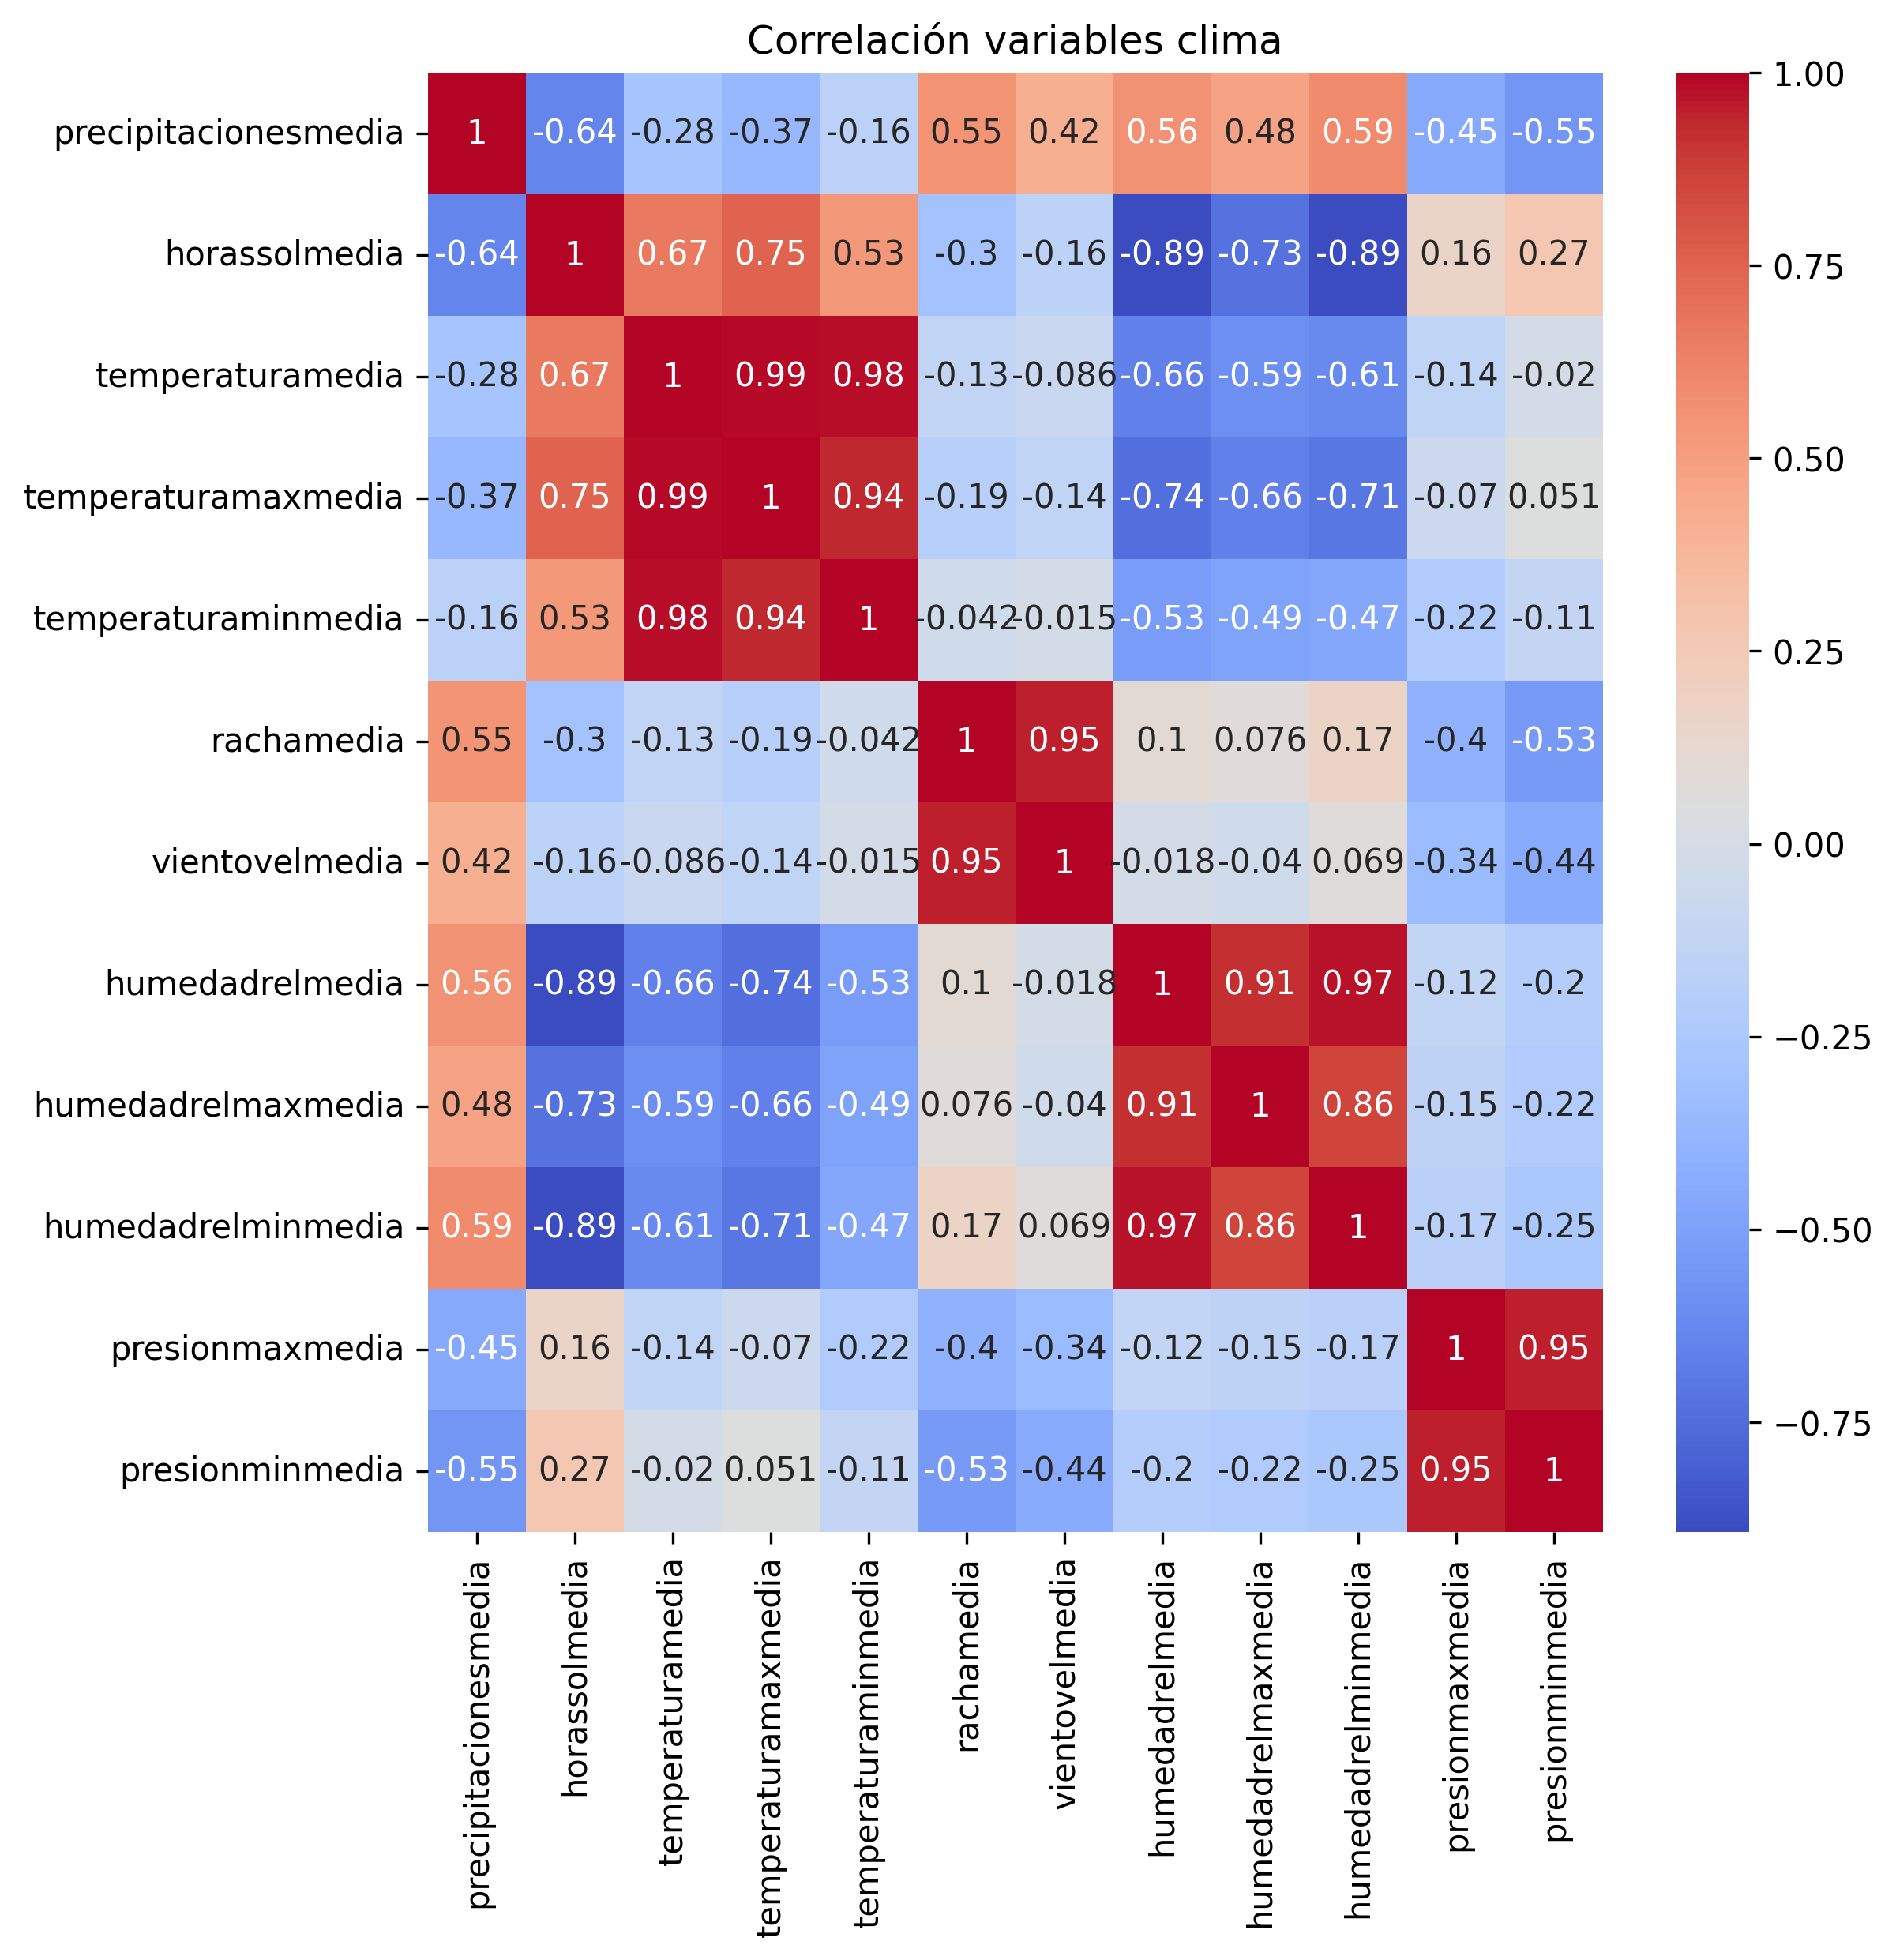

In [11]:
# Calcular la matriz de correlación para intentar descartar algunas variables que estén muy correlacionadas
matrizCorrelacion = dataframe_TFM[['precipitacionesmedia', 'horassolmedia', 'temperaturamedia', 'temperaturamaxmedia',
       'temperaturaminmedia', 'rachamedia', 'vientovelmedia',
       'humedadrelmedia', 'humedadrelmaxmedia', 'humedadrelminmedia',
       'presionmaxmedia', 'presionminmedia']].corr()[[
       'precipitacionesmedia', 'horassolmedia', 'temperaturamedia', 'temperaturamaxmedia',
       'temperaturaminmedia', 'rachamedia', 'vientovelmedia',
       'humedadrelmedia', 'humedadrelmaxmedia', 'humedadrelminmedia',
       'presionmaxmedia', 'presionminmedia']]# .sort_values(by='emisionestotal', ascending=False)

# Mostrar la matriz de correlación
print(matrizCorrelacion)

# Generar un mapa de calor para las correlaciones
plt.figure(figsize=(8, 8), dpi=300)
sns.heatmap(matrizCorrelacion, annot=True, cmap='coolwarm', cbar=True)
plt.title('Correlación variables clima')
plt.show()

Vemos que existen diferentes variables que estan fuertemente relacionadas entre si, en este caso vamos a seleccionar las siguientes columnas:

- precipitacionesmedia
- temperaturamedia
- rachamedia
- humedadrelmedia
- presionminmedia

las columnas restantes las hemos descartado porque existe una fuerte correlación enntre ellas, y alguna de las variables que hemos seleccionado, por tanto no nos van a aportar mucha información, solo harán que los modelos de predicción sean más pesados

In [13]:
# Eliminamos las columnas 
columnasSelec = [
       'Año', 'Mes', 'Dia', 'DiaSemana', 'SumaGeneracion_NoRenovables',
       'SumaGeneracion_Renovables',  'valordemanda', 'emisionestotal', 'emisionespormwh',
       'precipitacionesmedia', 'temperaturamedia', 'rachamedia',
       'humedadrelmedia', 'presionminmedia'
    ]

# Reorganizar el DataFrame con el nuevo orden de columnas
dataframe_TFM = dataframe_TFM[columnasSelec]

                             emisionestotal
emisionestotal                     1.000000
emisionespormwh                    0.960664
SumaGeneracion_NoRenovables        0.911512
valordemanda                       0.516752
Mes                                0.178978
presionminmedia                    0.136153
temperaturamedia                   0.134644
Dia                                0.008664
humedadrelmedia                   -0.085286
precipitacionesmedia              -0.164463
DiaSemana                         -0.182138
rachamedia                        -0.316332
Año                               -0.656521
SumaGeneracion_Renovables         -0.689432


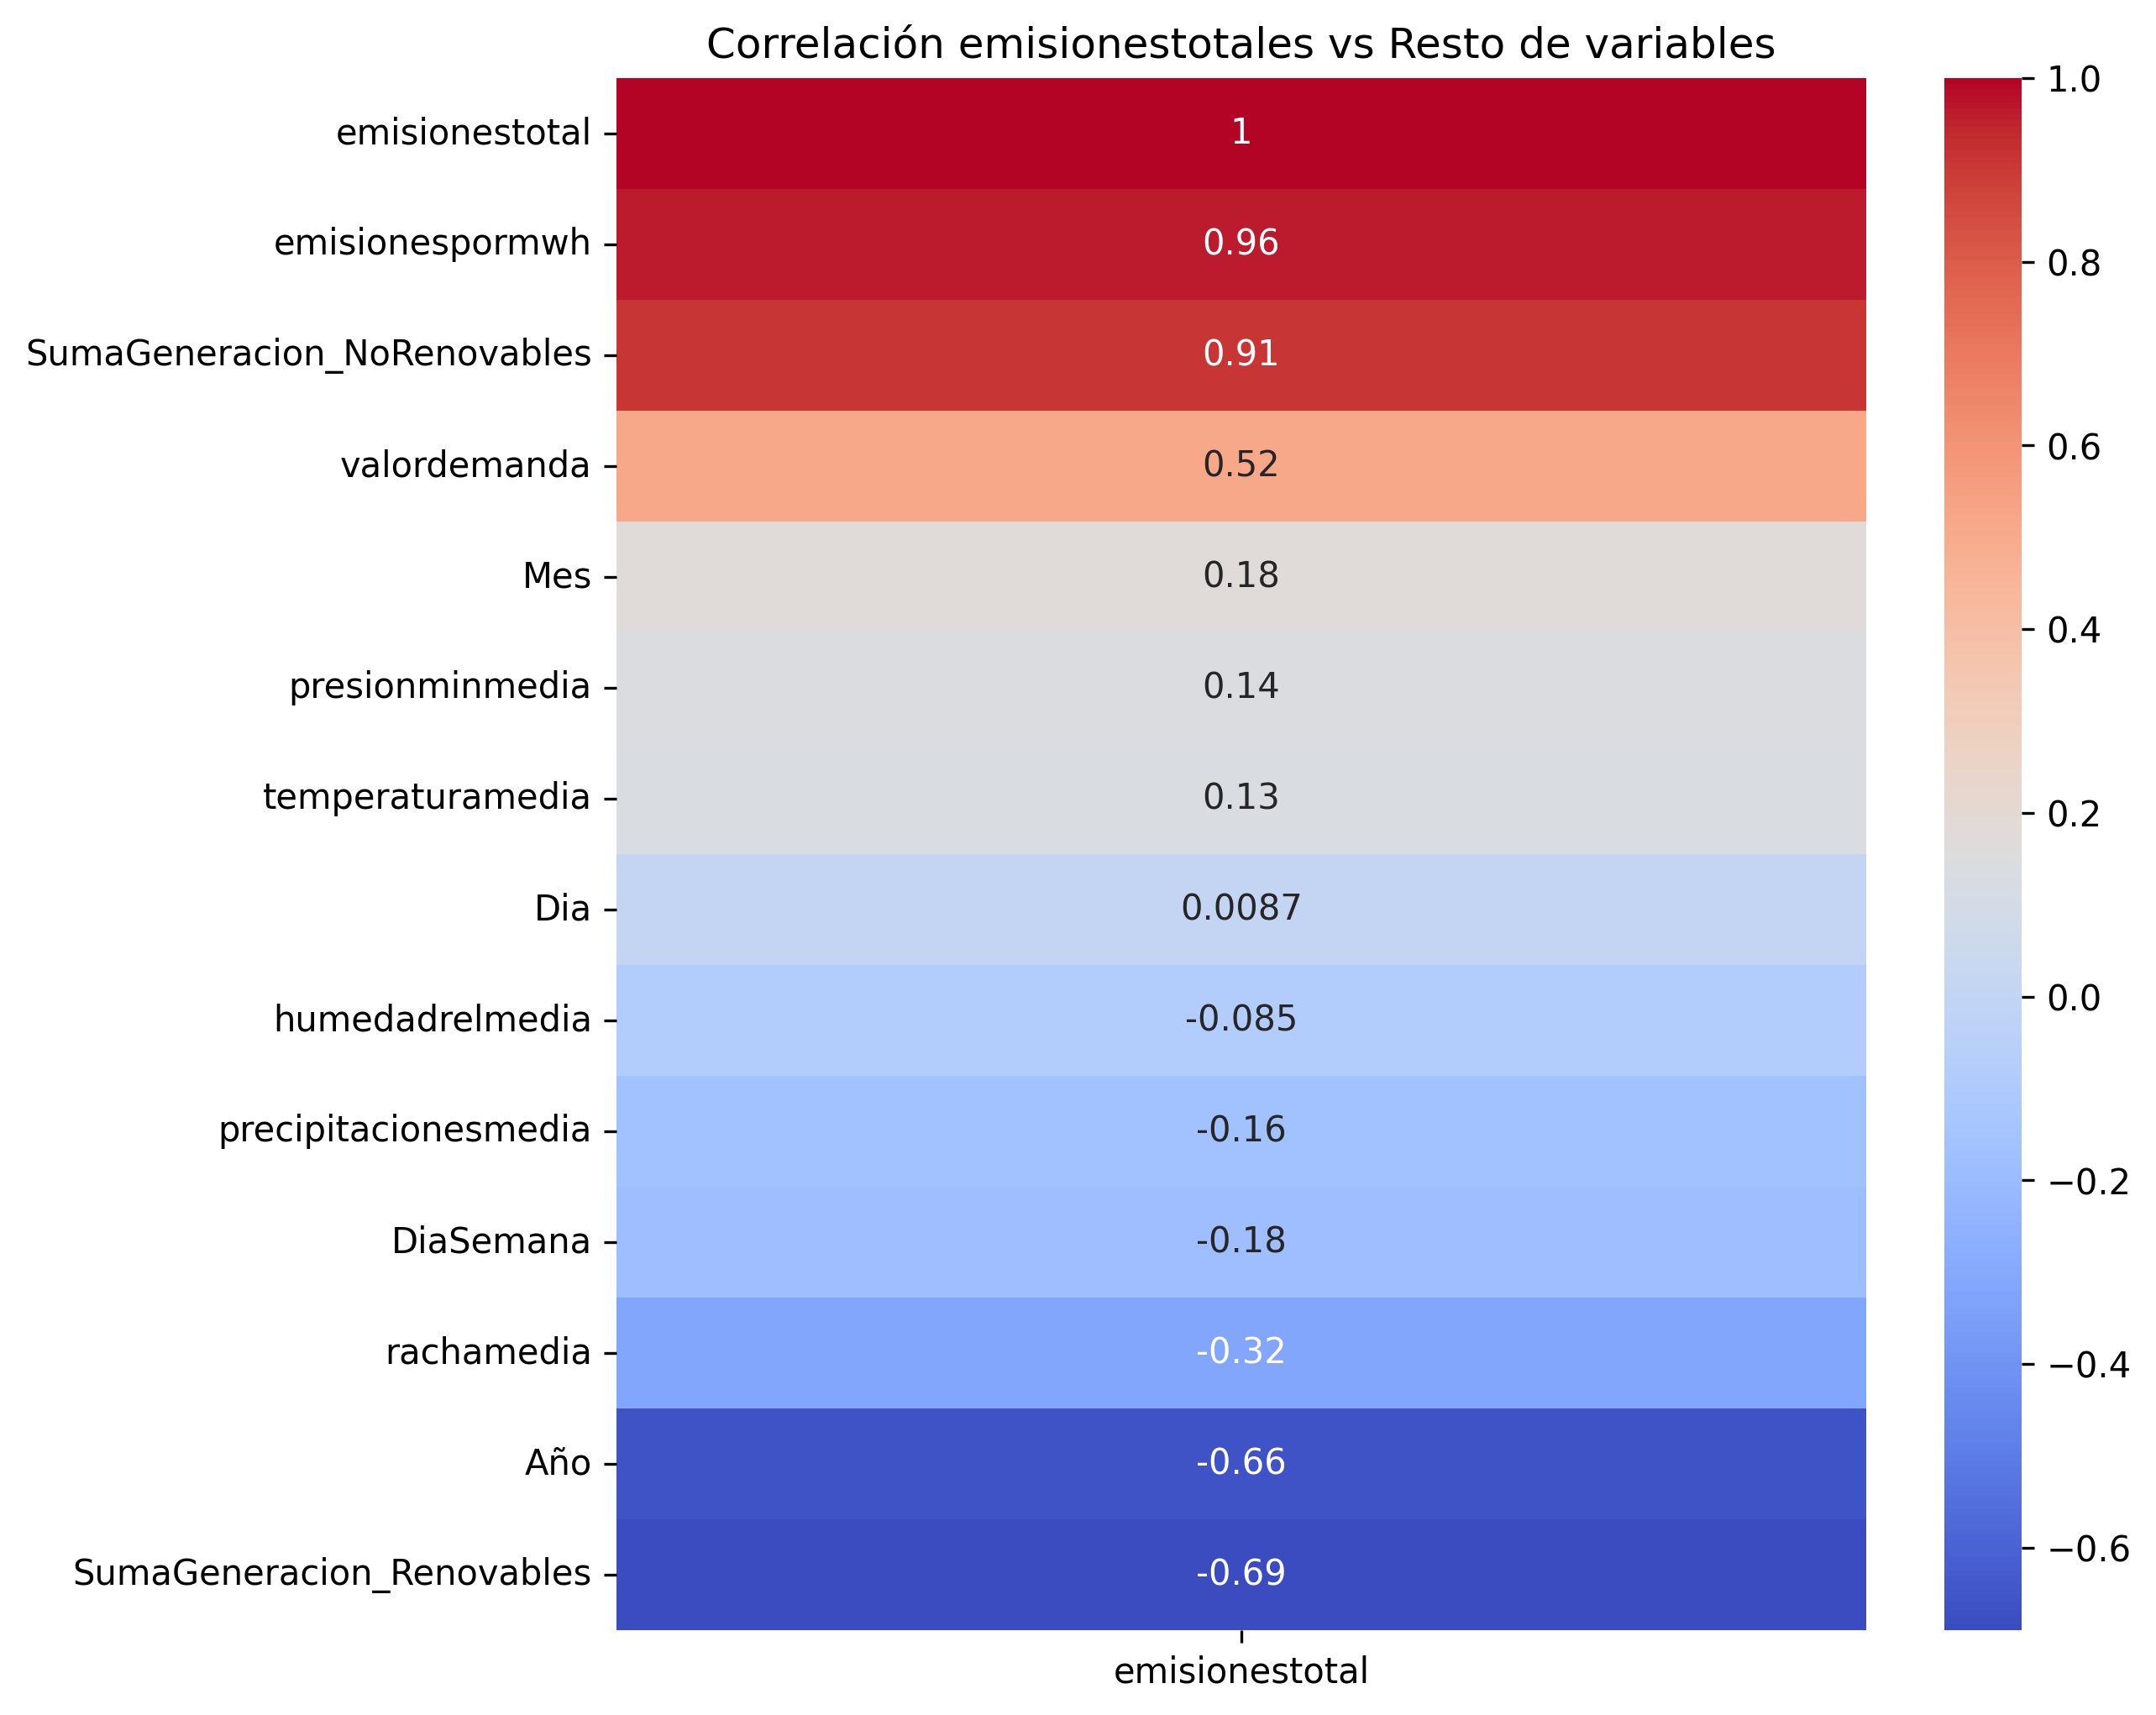

In [14]:
# Calcular la matriz de correlación solo con respecto a la variable 'emisionestotal'
matrizCorrelacion = dataframe_TFM.corr()[['emisionestotal']].sort_values(by='emisionestotal', ascending=False)

# Mostrar la matriz de correlación
print(matrizCorrelacion)

# Generar un mapa de calor para las correlaciones
plt.figure(figsize=(8, 8), dpi=300)
sns.heatmap(matrizCorrelacion, annot=True, cmap='coolwarm', cbar=True)
plt.title('Correlación emisionestotales vs Resto de variables')
plt.savefig('correlacion_emisionestotales.jpg')
plt.show()

Para evitar que el modelo se pueda basar en una variable demasiado correlacionada con la columna a predecir vamos a excluir la columna de emisionespormwh para la predicción. las otras las vamos a dejar de momento y la excluiremos en un futuro si es necesario.

Pasamos por último a arreglar estos datos para poder hacer los modelos de predicción.

Lo primero que vamos a hacer es crear dos dataframe, uno que corresponde con los datos que 
se usarán para la predicción (X) y otro que será la columna a predecir (Y)('emisionestotal')

Continuaremos realizando una selección de atributos, excluyendo columnas que estén demasiado correlacionadas

Luego normalizaremos los datos de X, esto ayuda a que el modelo funcione mejor

Por último vamos a separar los datos en 2 sets, uno de entrenamiento (X_train) y otro de test (X_test).

Nos saltaremos dos pasos, la detección de outliers, para contar con todos los datos,
y la compensación de valores ausentes, que como hemos visto, no hya valores nulos

## Creación X e Y

In [18]:
columnasX = [
       'Año', 'Mes', 'Dia', 'DiaSemana', 'SumaGeneracion_Renovables', 
       'valordemanda', 'precipitacionesmedia', 'temperaturamedia',
       'rachamedia', 'humedadrelmedia', 'presionminmedia'
    ]

columnasY = ['emisionestotal']

# Creación de los dataframe X e Y
X = dataframe_TFM[columnasX]
Y = dataframe_TFM[columnasY]/10000
# Dividimos entre 10000 para disminuir los valores, que como vimos en el análisis sus valores varían entre 40.000 y 360.000

## Selección de atributos

In [20]:
# Evaluación de atributos: F-Test.
f_test, p_value = f_regression(X, Y) # Llamamos al estadístico F

# Definimos el valor de significancia (alpha)
alpha = 0.01

# Definimos la decisión de si aceptamos o rechazamos la hipótesis nula (Ho) para cada variable
for i in range(len(p_value)):
    p_val = p_value[i]
    
    if p_val<alpha:
        h = 1 # Se rechaza la hipótesis nula que defiende la independencia entre variables. Por tanto, DEPENDIENTES.
        print(colored('La variable ' + str(i) + ' es linealmente DEPENDIENTE de la clase. p-value: ' + str(p_val), 'green'))
    else:
        h = 0 # No hay evidencia estadística para rechazar la hipótesis nula, por tanto, se asume INDEPENDENCIA entre variables
        print(colored('La variable ' + str(i) + ' es linealmente INDEPENDIENTE de la clase. p-value: ' + str(p_val), 'red'))

La variable 0 es linealmente DEPENDIENTE de la clase. p-value: 0.0
La variable 1 es linealmente DEPENDIENTE de la clase. p-value: 4.486241330419711e-38
La variable 2 es linealmente INDEPENDIENTE de la clase. p-value: 0.5356465394974559
La variable 3 es linealmente DEPENDIENTE de la clase. p-value: 2.162565092732909e-39
La variable 4 es linealmente DEPENDIENTE de la clase. p-value: 0.0
La variable 5 es linealmente DEPENDIENTE de la clase. p-value: 0.0
La variable 6 es linealmente DEPENDIENTE de la clase. p-value: 2.4559851576306233e-32
La variable 7 es linealmente DEPENDIENTE de la clase. p-value: 4.0275226627955616e-22
La variable 8 es linealmente DEPENDIENTE de la clase. p-value: 3.2285552120652504e-119
La variable 9 es linealmente DEPENDIENTE de la clase. p-value: 1.004842956287279e-09
La variable 10 es linealmente DEPENDIENTE de la clase. p-value: 1.375290223334947e-22


C:\Users\sergi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Con esto hemos detectado, mediante un F-test, si alguna de las variables está demasiado poco correlacionada con las emisiones totales, y nos ha devuelto que la tercera variable, que es la columna dia, no esta suficientemente correlacionada con las emisiones, por tanto la vamos a excluir del análisis.

In [22]:
columnasX = [
       'Año', 'Mes', 'DiaSemana', 'SumaGeneracion_Renovables', 
       'valordemanda', 'precipitacionesmedia', 'temperaturamedia',
       'rachamedia', 'humedadrelmedia', 'presionminmedia'
    ]

# Creación de los dataframe X e Y
X = X[columnasX]
print(X)

       Año  Mes  DiaSemana  SumaGeneracion_Renovables  valordemanda  \
0     2011    1          6                182024.9820    605986.216   
1     2011    1          7                265705.8895    641856.087   
2     2011    1          1                249489.5735    801297.365   
3     2011    1          2                270981.7130    833253.263   
4     2011    1          3                379833.0150    803475.573   
...    ...  ...        ...                        ...           ...   
5109  2024   12          5                287962.8495    675212.456   
5110  2024   12          6                253551.5200    641243.762   
5111  2024   12          7                216941.5465    618610.074   
5112  2024   12          1                232128.6595    690745.398   
5113  2024   12          2                212505.9490    665712.737   

      precipitacionesmedia  temperaturamedia  rachamedia  humedadrelmedia  \
0                 0.543280          9.304667    5.622409        86.440

## Normalización

In [24]:
# Limpieza de datos: normalización.
normalizer = preprocessing.MinMaxScaler()
X_norm = normalizer.fit_transform(X)

## Dividir los datos en 2 conjuntos de datos (test, train)

In [26]:
# TRAIN y TEST

# Semilla para poder reproducir los pasos en eventos de aleatorieidad
seed_random_state=42

# Dividimos los datos en entrenamiento (80%) y prueba (20%)
X_train_norm, X_test_norm, Y_train, Y_test = train_test_split(X_norm, Y, test_size=0.2, random_state=seed_random_state)


# Mostramos el tamaño de cada conjunto
(X_train_norm.shape, X_test_norm.shape)

((4091, 10), (1023, 10))

In [27]:
# Métricas de evaluación.
metricas = {
    'MAE': 'neg_mean_absolute_error',
    'MSE': 'neg_mean_squared_error',
    'RMSE': make_scorer(lambda y, y_pred:
                      sqrt(mean_squared_error(y, y_pred)),
                      greater_is_better=False),
    'MAPE': make_scorer(lambda y, y_pred:
                      np.mean(np.abs((y - y_pred) / y)) * 100,
                      greater_is_better=False)}

## Primer modelo, Regresión Lineal Multiple

In [29]:
# Construcción del algoritmo de aprendizaje.
reg = linear_model.LinearRegression(fit_intercept=True)

{'fit_time': array([0.03864455, 0.        , 0.01424837, 0.01479864, 0.01395965]),
 'score_time': array([0.        , 0.        , 0.00105119, 0.00110435, 0.00100565]),
 'test_MAE': array([-2.41217438, -2.44481007, -2.35754089, -2.50562254, -2.37784812]),
 'test_MAPE': array([-19.06014208, -19.80122439, -19.10586163, -19.18634966,
       -19.10507231]),
 'test_MSE': array([-8.68133695, -8.90276208, -8.20313498, -9.0315472 , -8.327309  ]),
 'test_RMSE': array([-2.94641086, -2.98374967, -2.86411155, -3.00525327, -2.88570771])}
MAE:  2.3297
MSE: 8.0240
RMSE: 2.8327
R2:   0.8445


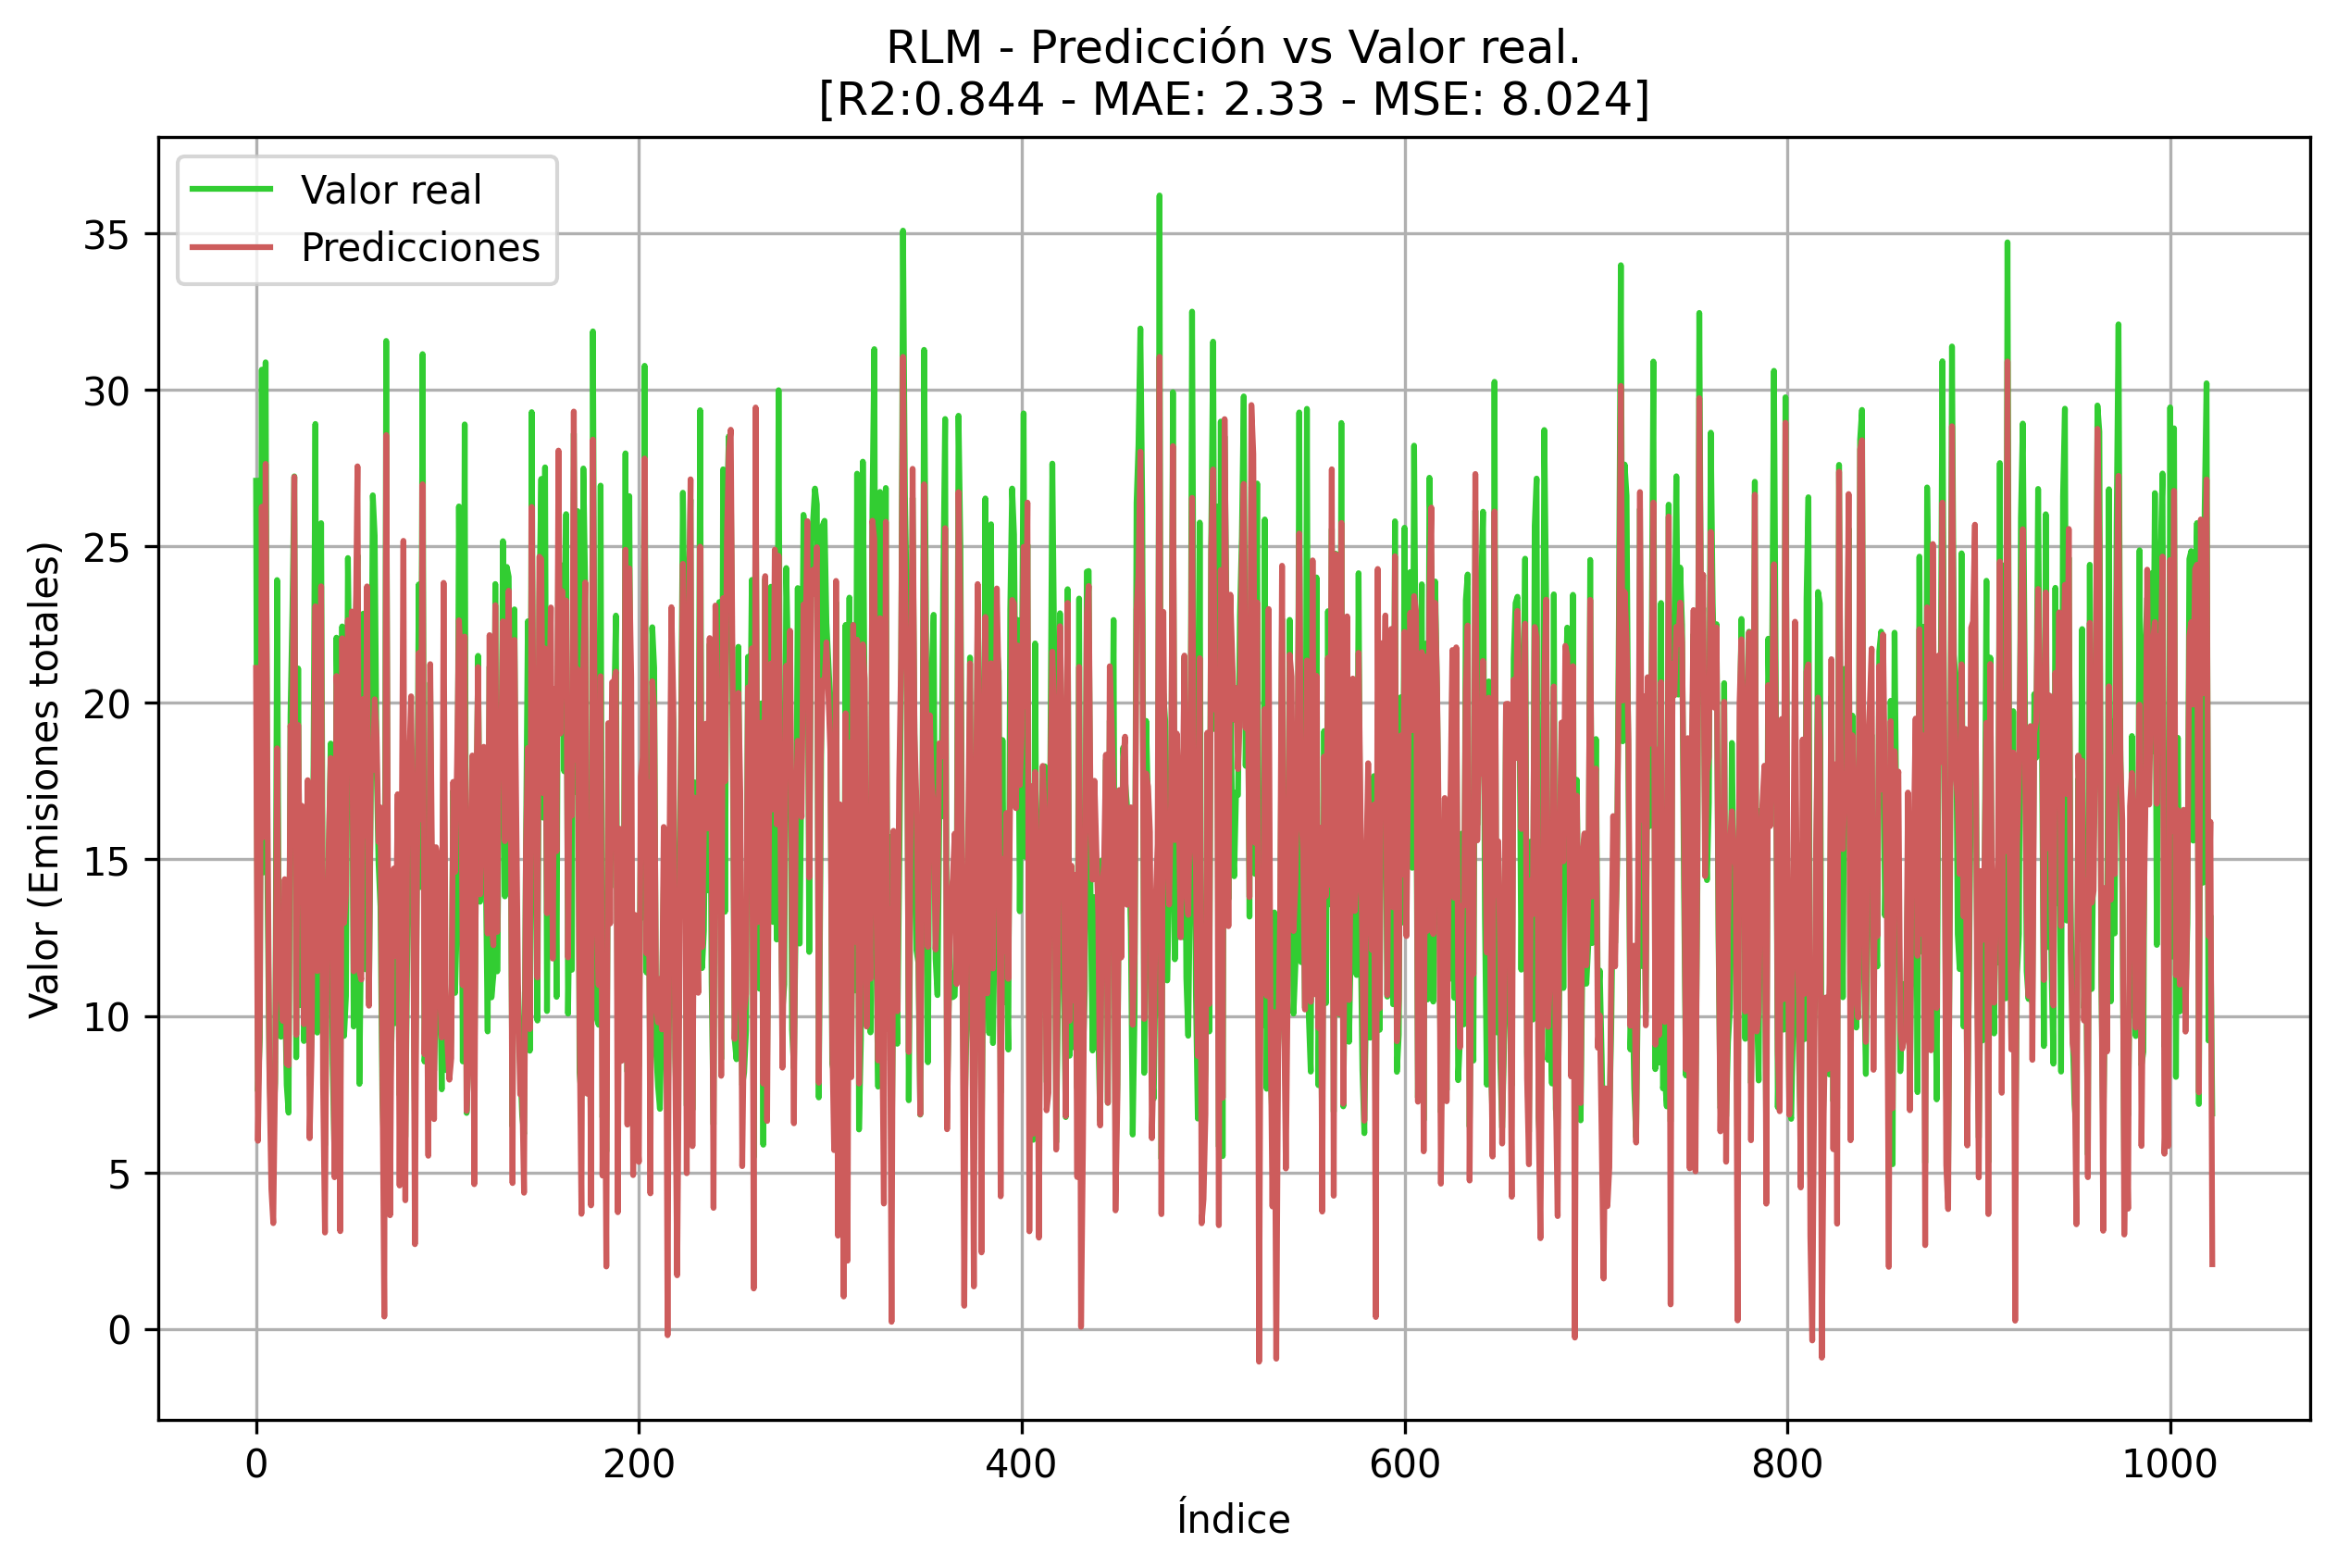

In [30]:
#  Validación cruzada interna

# Extraer directamente resultados del error para cada bolsa, en lugar de las predicciones
cross_val_results = cross_validate(reg, X_train_norm, Y_train, 
                                    cv = KFold(n_splits=5, shuffle=True, random_state=42), scoring=metricas)
# print("cross_val_R2:   %0.4f +/- %0.4f" % (-cross_val_results.mean(), cross_val_results.std()))
pprint(cross_val_results)

# Entrenamiento con todos los datos para obtener los coeficientes del modelo.
model = reg.fit(X_train_norm, Y_train)

# 9) Predicción del conjunto de test
y_pred_test = model.predict(X_test_norm)

# 10) Cálculo de las métricas de evaluación.
MAE = metrics.mean_absolute_error(Y_test, y_pred_test)
MSE = metrics.mean_squared_error(Y_test, y_pred_test)
RMSE = metrics.root_mean_squared_error(Y_test, y_pred_test)
R2 = metrics.r2_score(Y_test, y_pred_test)

print('MAE:  %.4f' % MAE)
print('MSE: %.4f' % MSE)
print('RMSE: %.4f' % RMSE)
print('R2:   %.4f' % R2)


descripcion = f'RLM - Predicción vs Valor real.'
visualizarPrediccionesValorReal(Y_test, y_pred_test, descripcion, MAE, MSE, R2)


## Segundo Modelo SVR

In [32]:


svr = SVR(kernel='rbf', degree=3, gamma='scale', coef0=0.0, tol=0.001,
                 C=1.0, epsilon=0.1, shrinking=True, cache_size=200, verbose=False,
                 max_iter=-1)
# 1. Definición del modelo SVR (Parámetros por defecto)
svr_modelo = cross_validate(svr, X_train_norm, np.ravel(Y_train), 
                            cv = KFold(n_splits=5, shuffle=True, random_state=42), scoring=metricas)

pprint(cross_val_results)


# 2. Entrenamiento del modelo (Datos: X_train)
model = svr.fit(X_train_norm, np.ravel(Y_train))

# 3. Predicción del Porcentaje_Renovable (Datos: X_test)
y_pred_svr = model.predict(X_test_norm)

# 4. Cálculo de las métricas de evaluación (Y_test vs y_pred)
MAE = metrics.mean_absolute_error(Y_test, y_pred_svr)
MSE = metrics.mean_squared_error(Y_test, y_pred_svr)
RMSE = metrics.root_mean_squared_error(Y_test, y_pred_svr)
R2 = metrics.r2_score(Y_test, y_pred_svr)

print('MAE:  %.4f' % MAE)
print('MSE: %.4f' % MSE)
print('RMSE: %.4f' % RMSE)
print('R2:   %.4f' % R2)


{'fit_time': array([0.03864455, 0.        , 0.01424837, 0.01479864, 0.01395965]),
 'score_time': array([0.        , 0.        , 0.00105119, 0.00110435, 0.00100565]),
 'test_MAE': array([-2.41217438, -2.44481007, -2.35754089, -2.50562254, -2.37784812]),
 'test_MAPE': array([-19.06014208, -19.80122439, -19.10586163, -19.18634966,
       -19.10507231]),
 'test_MSE': array([-8.68133695, -8.90276208, -8.20313498, -9.0315472 , -8.327309  ]),
 'test_RMSE': array([-2.94641086, -2.98374967, -2.86411155, -3.00525327, -2.88570771])}
MAE:  1.6013
MSE: 4.3792
RMSE: 2.0926
R2:   0.9151


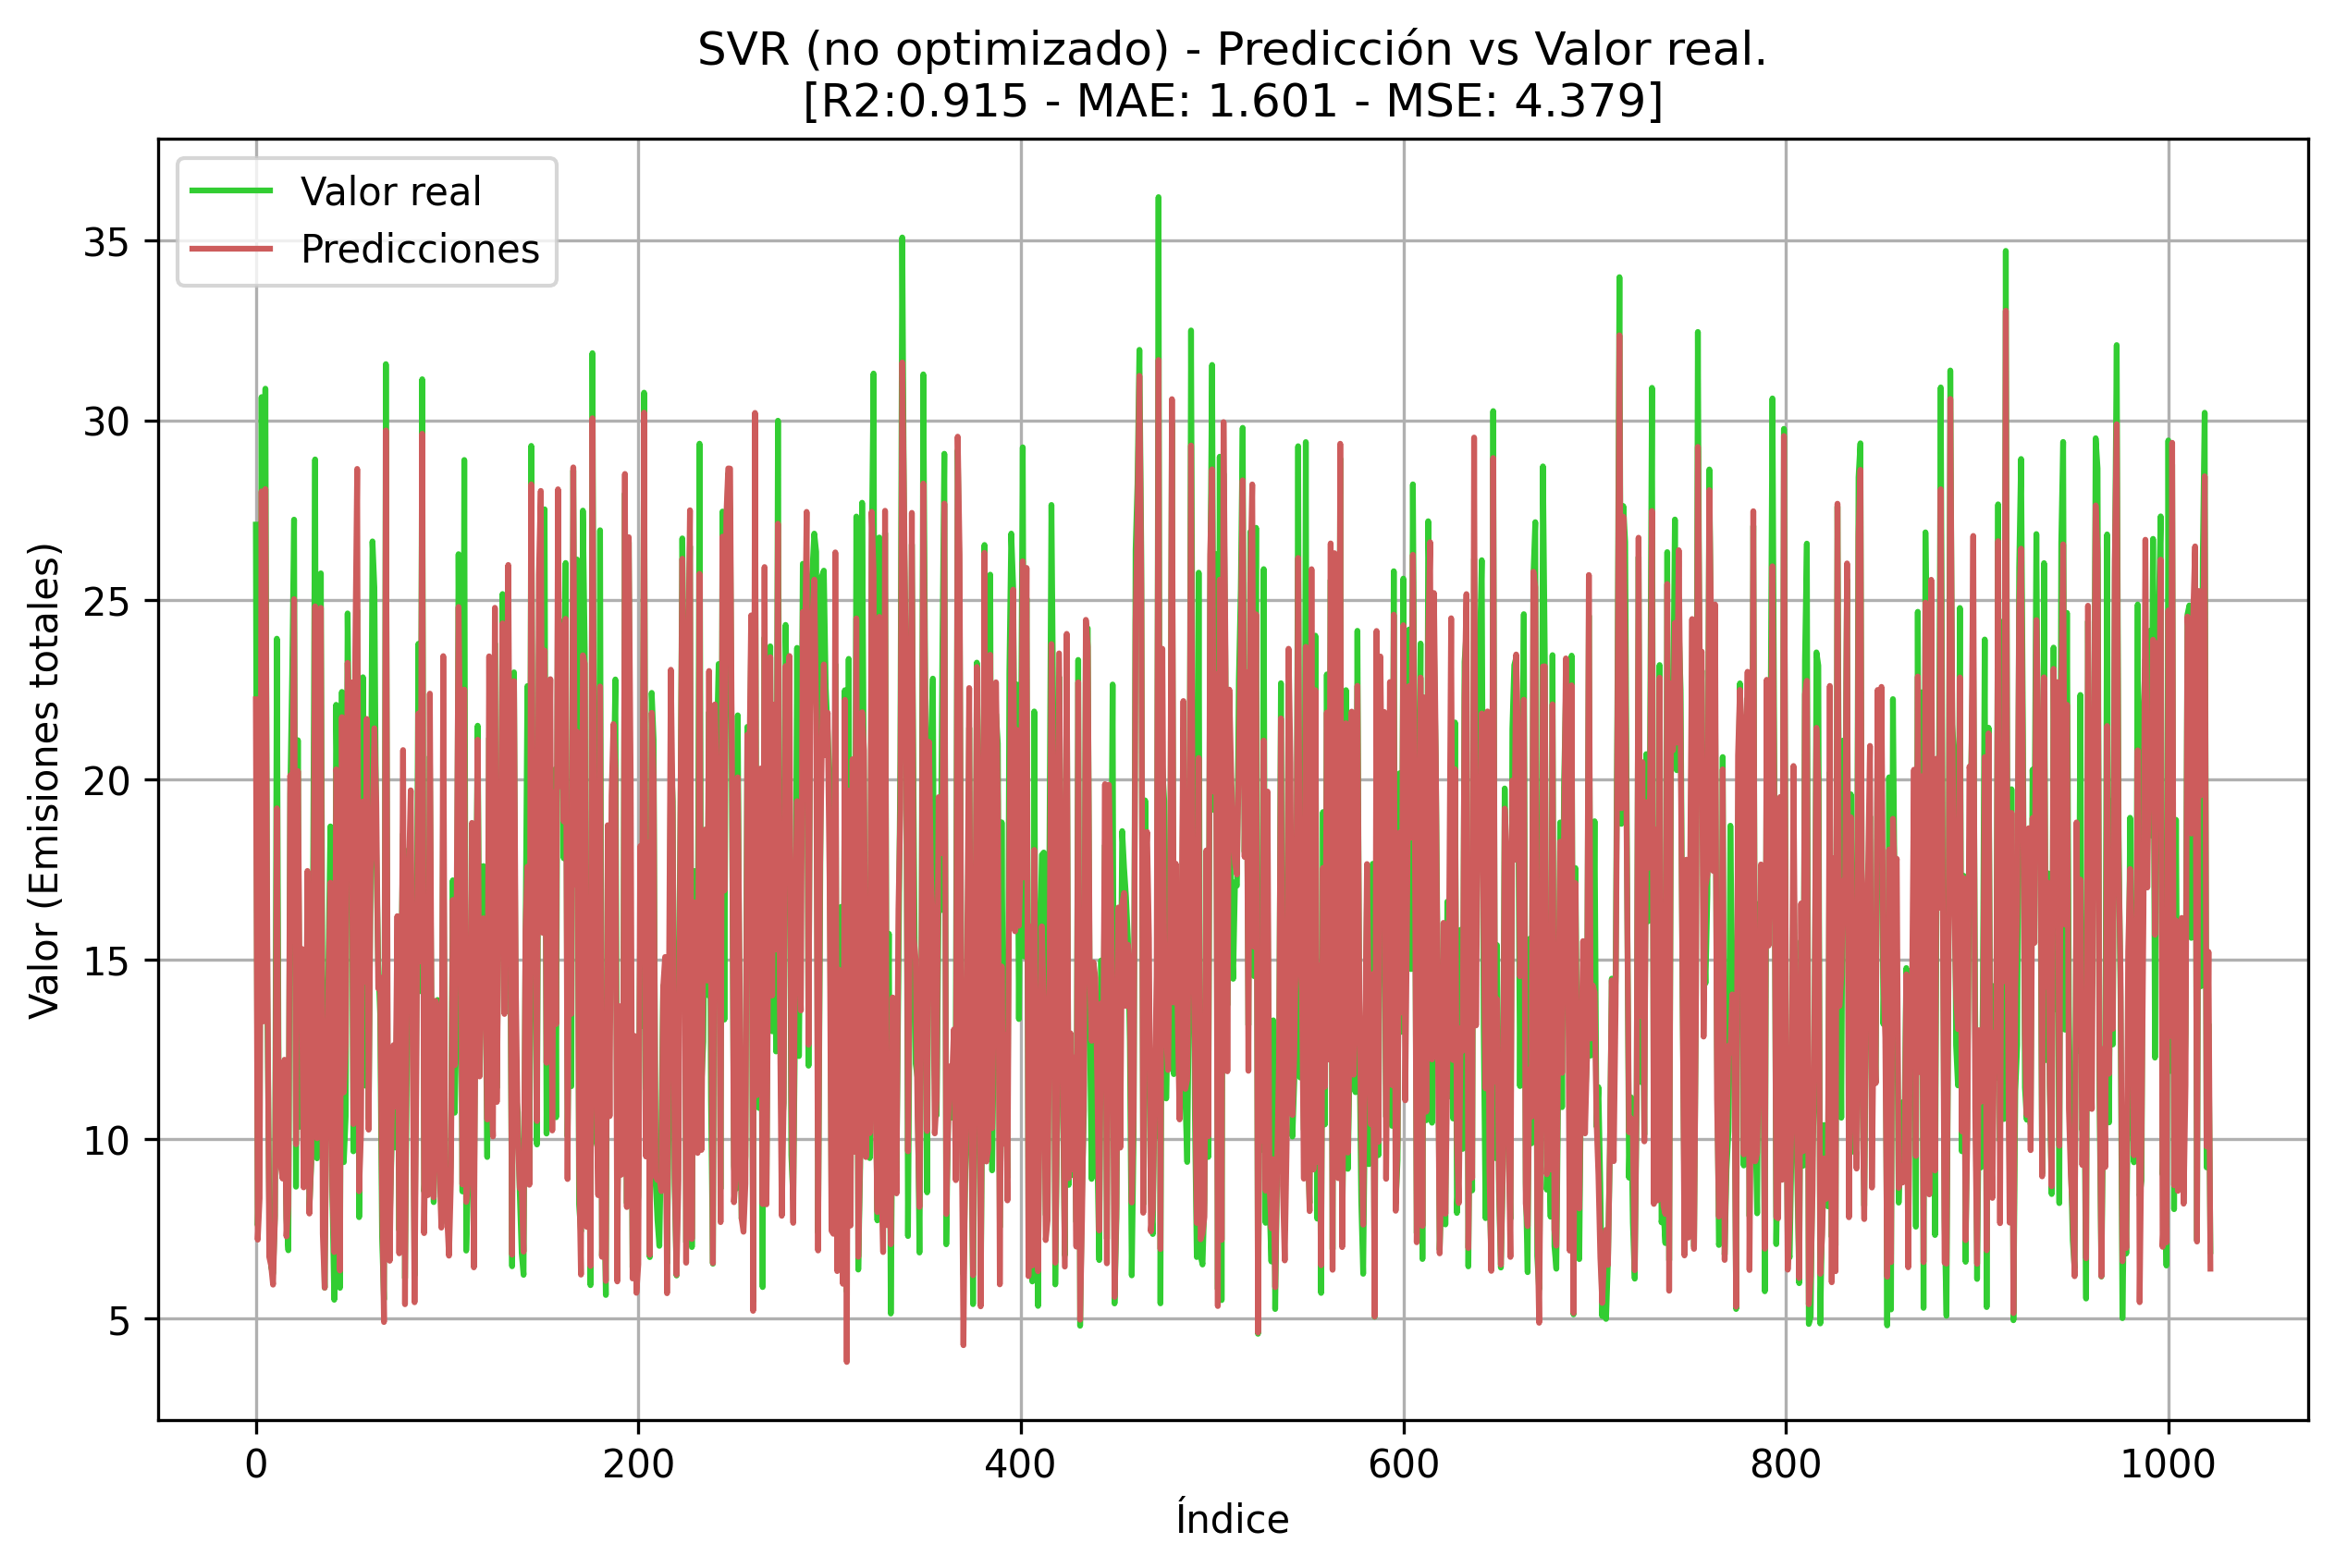

In [33]:
descripcion = f'SVR (no optimizado) - Predicción vs Valor real.'
visualizarPrediccionesValorReal(Y_test, y_pred_svr, descripcion, MAE, MSE, R2)


In [34]:
# 1. Parametrizar la búsqueda de RandomizedSearchCV
parametros_RSCV_svr = {
    'C': np.logspace(-3, 2, 6),  # Probar valores de C desde 0.001 hasta 100
    'epsilon': np.linspace(0.01, 1, 10),  # Probar valores de epsilon desde 0.01 hasta 1
    'kernel': ['rbf', 'linear']  # Probar con kernel radial y lineal
}

# 2. Configuración RandomizedSearchCV
randomizedSearch_svr = RandomizedSearchCV(SVR(),
                                          n_iter=20,  # 20 iteraciones
                                          cv=5,       # Validación cruzada
                                          param_distributions=parametros_RSCV_svr,
                                          scoring='neg_mean_squared_error',
                                          random_state=seed_random_state) #42

# 3. Entrenamiento RandomizedSearchCV (Datos X_train)
randomizedSearch_svr.fit(X_train_norm,  np.ravel(Y_train))

# Obtener los mejores parámetros del RandomizedSearchCV
bestRandomSearch_svr = randomizedSearch_svr.best_estimator_
print(f"Mejores parámetros del RandomizedSearchCV: {randomizedSearch_svr.best_params_}")


Mejores parámetros del RandomizedSearchCV: {'kernel': 'rbf', 'epsilon': 0.23, 'C': 100.0}


In [140]:
from sklearn.model_selection import GridSearchCV

# 1. Parametrizar la búsqueda de GridSearchCV
parametros_grid_svr = {
    'C': np.linspace(bestRandomSearch_svr.C * 0.5,
                     bestRandomSearch_svr.C * 1.5,
                     5),
    'epsilon': np.linspace(bestRandomSearch_svr.epsilon * 0.5,
                           bestRandomSearch_svr.epsilon * 1.5,
                           5),
    'kernel': [bestRandomSearch_svr.kernel]  # Usar el mejor kernel encontrado
}

# 2. Configuración GridSearchCV
gridSearch_svr = GridSearchCV(SVR(), cv=5,
                               param_grid=parametros_grid_svr,
                               scoring='neg_mean_squared_error')

# 3. Entrenamiento GridSearchCV
gridSearch_svr.fit(X_train_norm, np.ravel(Y_train))

# 4. Mejores parámetros de GridSearchCV
bestGridSearch_svr = gridSearch_svr.best_estimator_
print(f"Mejores parámetros del GridSearchCV: {gridSearch_svr.best_params_}")


Mejores parámetros del GridSearchCV: {'C': 100.0, 'epsilon': 0.28750000000000003, 'kernel': 'rbf'}


In [141]:
# 1. Predicción utilizando el modelo optimizado por RandomSearch + GridSearch
y_pred_svr_optimizado = bestGridSearch_svr.predict(X_test_norm)

# 2. Cálculo de métricas: MAE, MSE y R2
mae_svr_optimizado = mean_absolute_error(Y_test, y_pred_svr_optimizado)
mse_svr_optimizado = mean_squared_error(Y_test, y_pred_svr_optimizado)
r2_svm_optimizado = r2_score(Y_test, y_pred_svr_optimizado)
print("SVR (optimizado) - Métricas TEST:")
print("MAE:", mae_svr_optimizado, "- MSE:", mse_svr_optimizado, " - R2:", r2_svm_optimizado)

SVR (optimizado) - Métricas TEST:
MAE: 1.3425812623131497 - MSE: 3.094721918406688  - R2: 0.9400224086148552


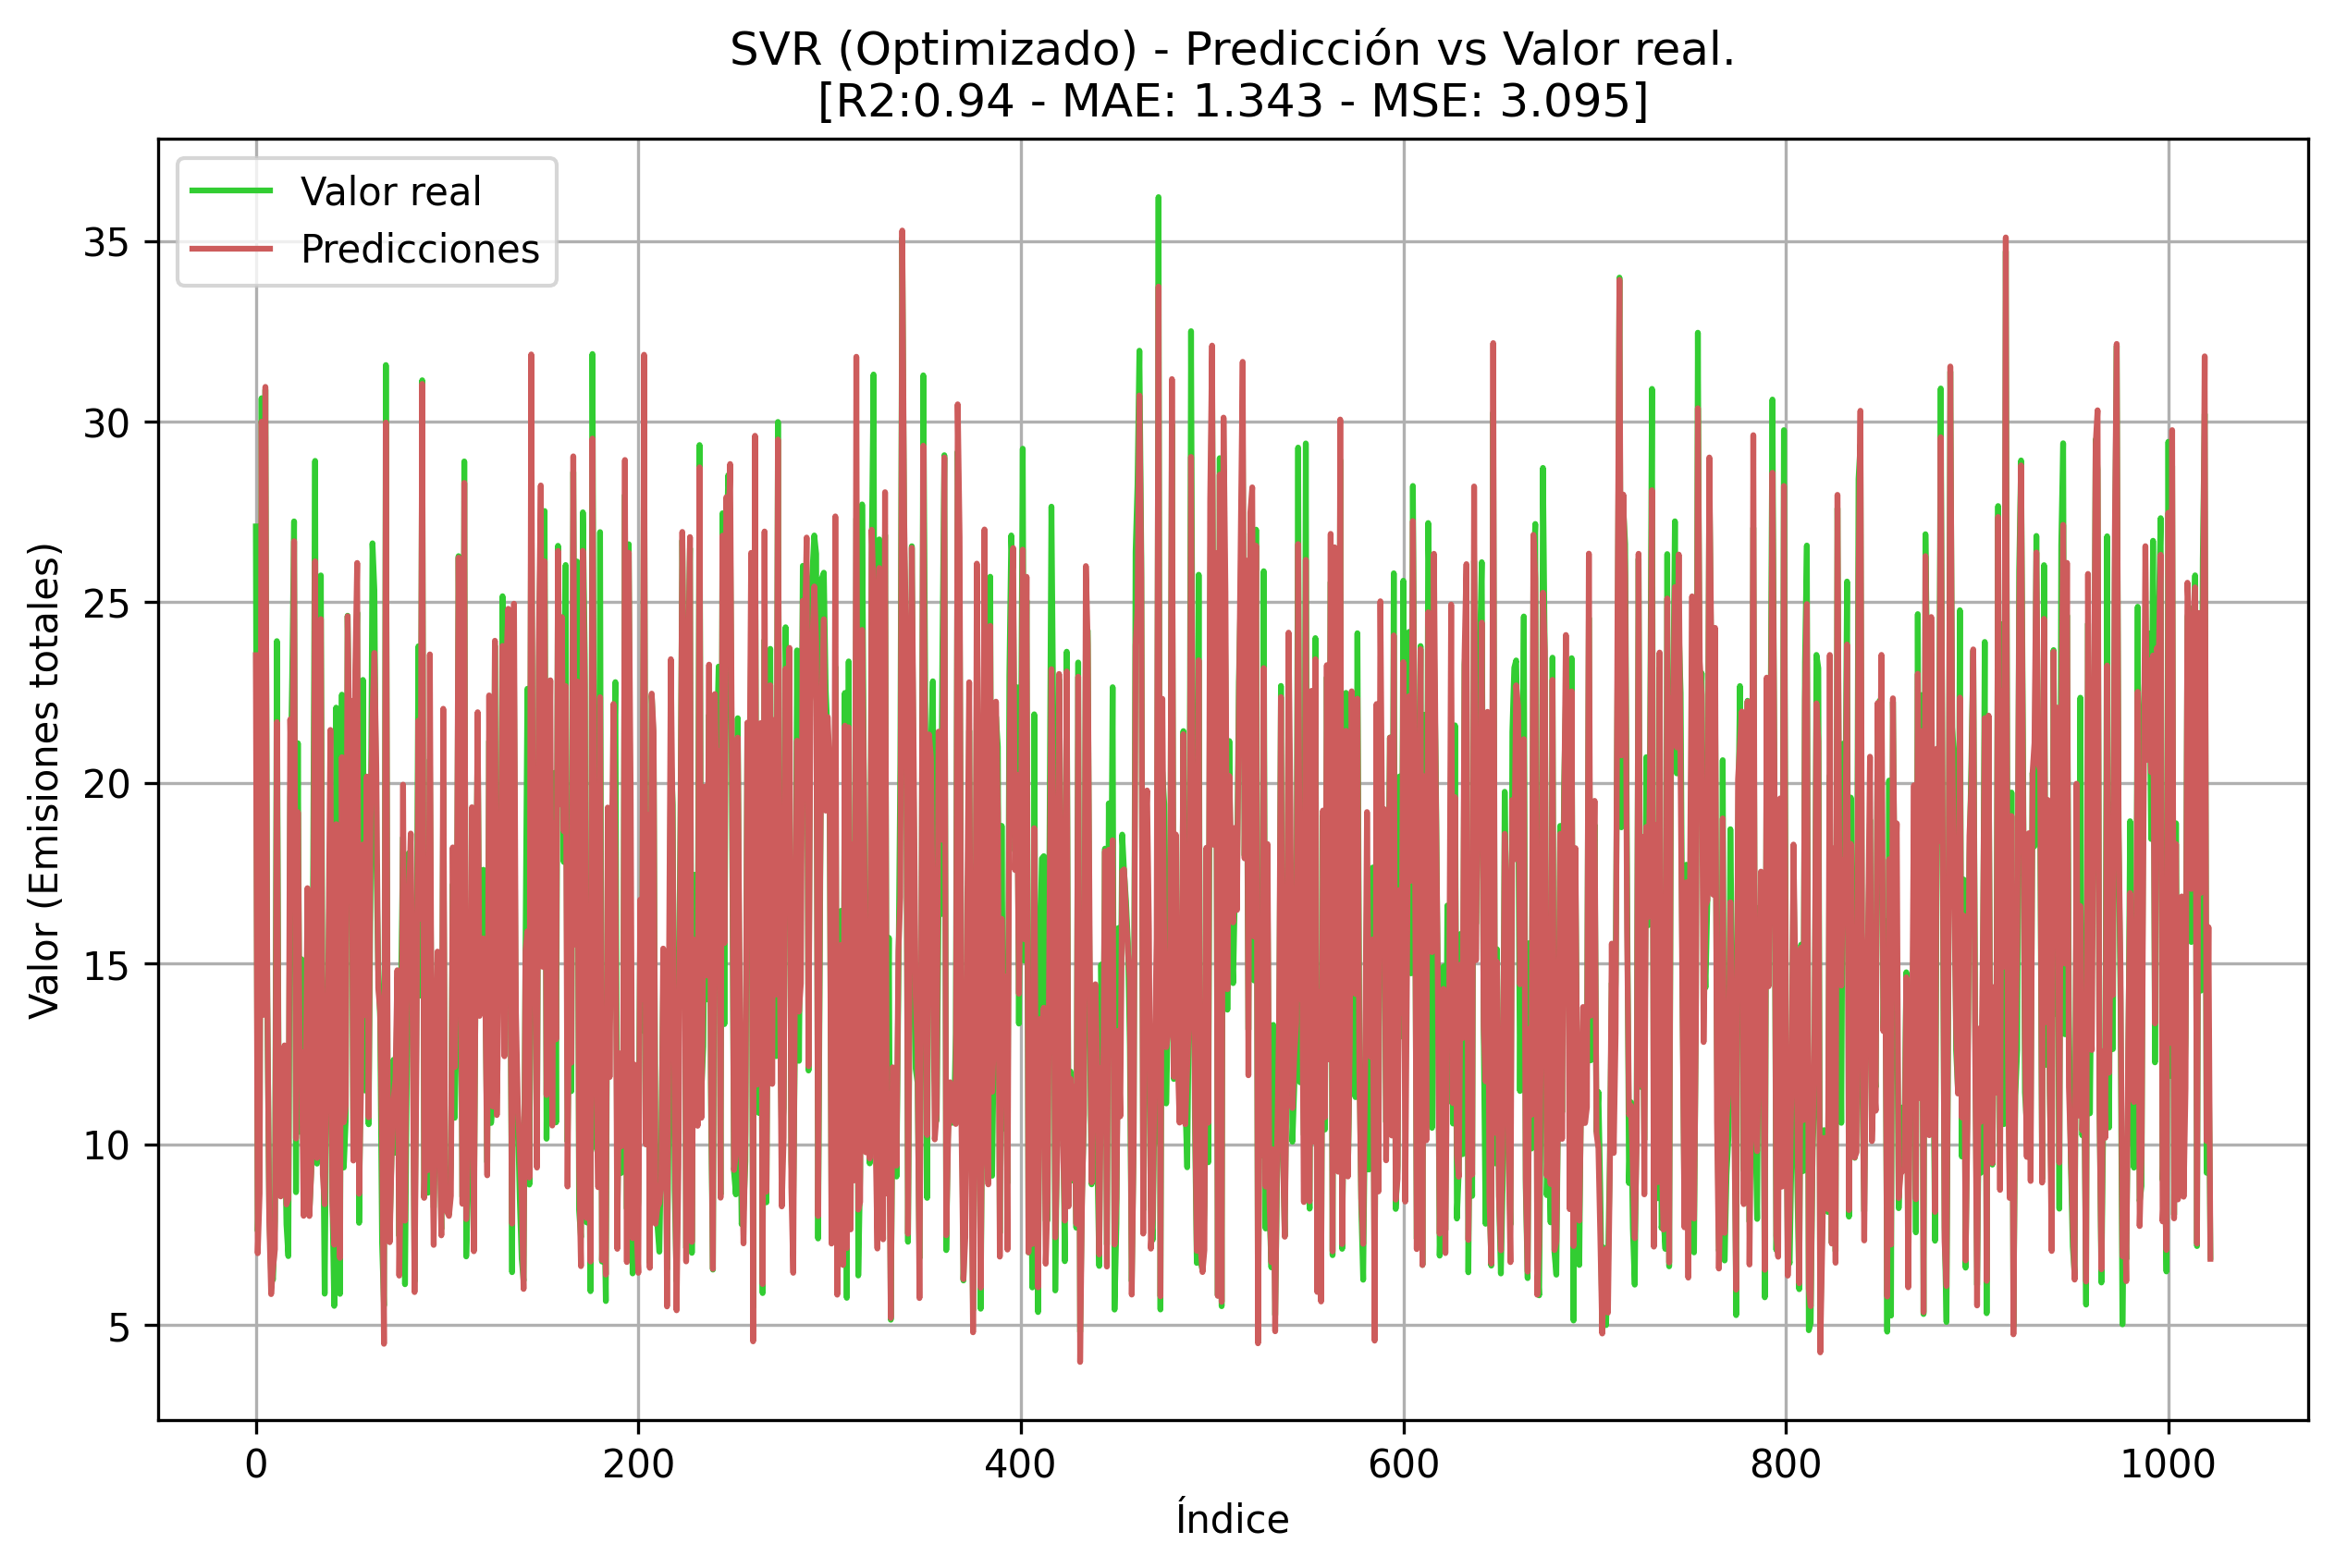

In [143]:
descripcion = f'SVR (Optimizado) - Predicción vs Valor real.'
visualizarPrediccionesValorReal(Y_test, y_pred_svr_optimizado, descripcion,
                                mae_svr_optimizado,
                                mse_svr_optimizado, r2_svm_optimizado)

In [35]:
svr = SVR(kernel='rbf', degree=3, gamma='scale', coef0=0.0, tol=0.001,
                 C=100.0, epsilon=0.23, shrinking=True, cache_size=200, verbose=False,
                 max_iter=-1)
# 1. Definición del modelo SVR (Parámetros por defecto)
svr_modelo = cross_validate(svr, X_train_norm,  np.ravel(Y_train), 
                            cv = KFold(n_splits=5, shuffle=True, random_state=42), scoring=metricas)
# 2. Entrenamiento del modelo (Datos: X_train)
model = svr.fit(X_train_norm, np.ravel(Y_train))

# 3. Predicción del Porcentaje_Renovable (Datos: X_test)
y_pred_svr = model.predict(X_test_norm)

# 4. Cálculo de las métricas de evaluación (Y_test vs y_pred)
MAE = metrics.mean_absolute_error(Y_test, y_pred_svr)
MSE = metrics.mean_squared_error(Y_test, y_pred_svr)
RMSE = metrics.root_mean_squared_error(Y_test, y_pred_svr)
R2 = metrics.r2_score(Y_test, y_pred_svr)

print('MAE:  %.4f' % MAE)
print('MSE: %.4f' % MSE)
print('RMSE: %.4f' % RMSE)
print('R2:   %.4f' % R2)


MAE:  1.3451
MSE: 3.1038
RMSE: 1.7618
R2:   0.9398


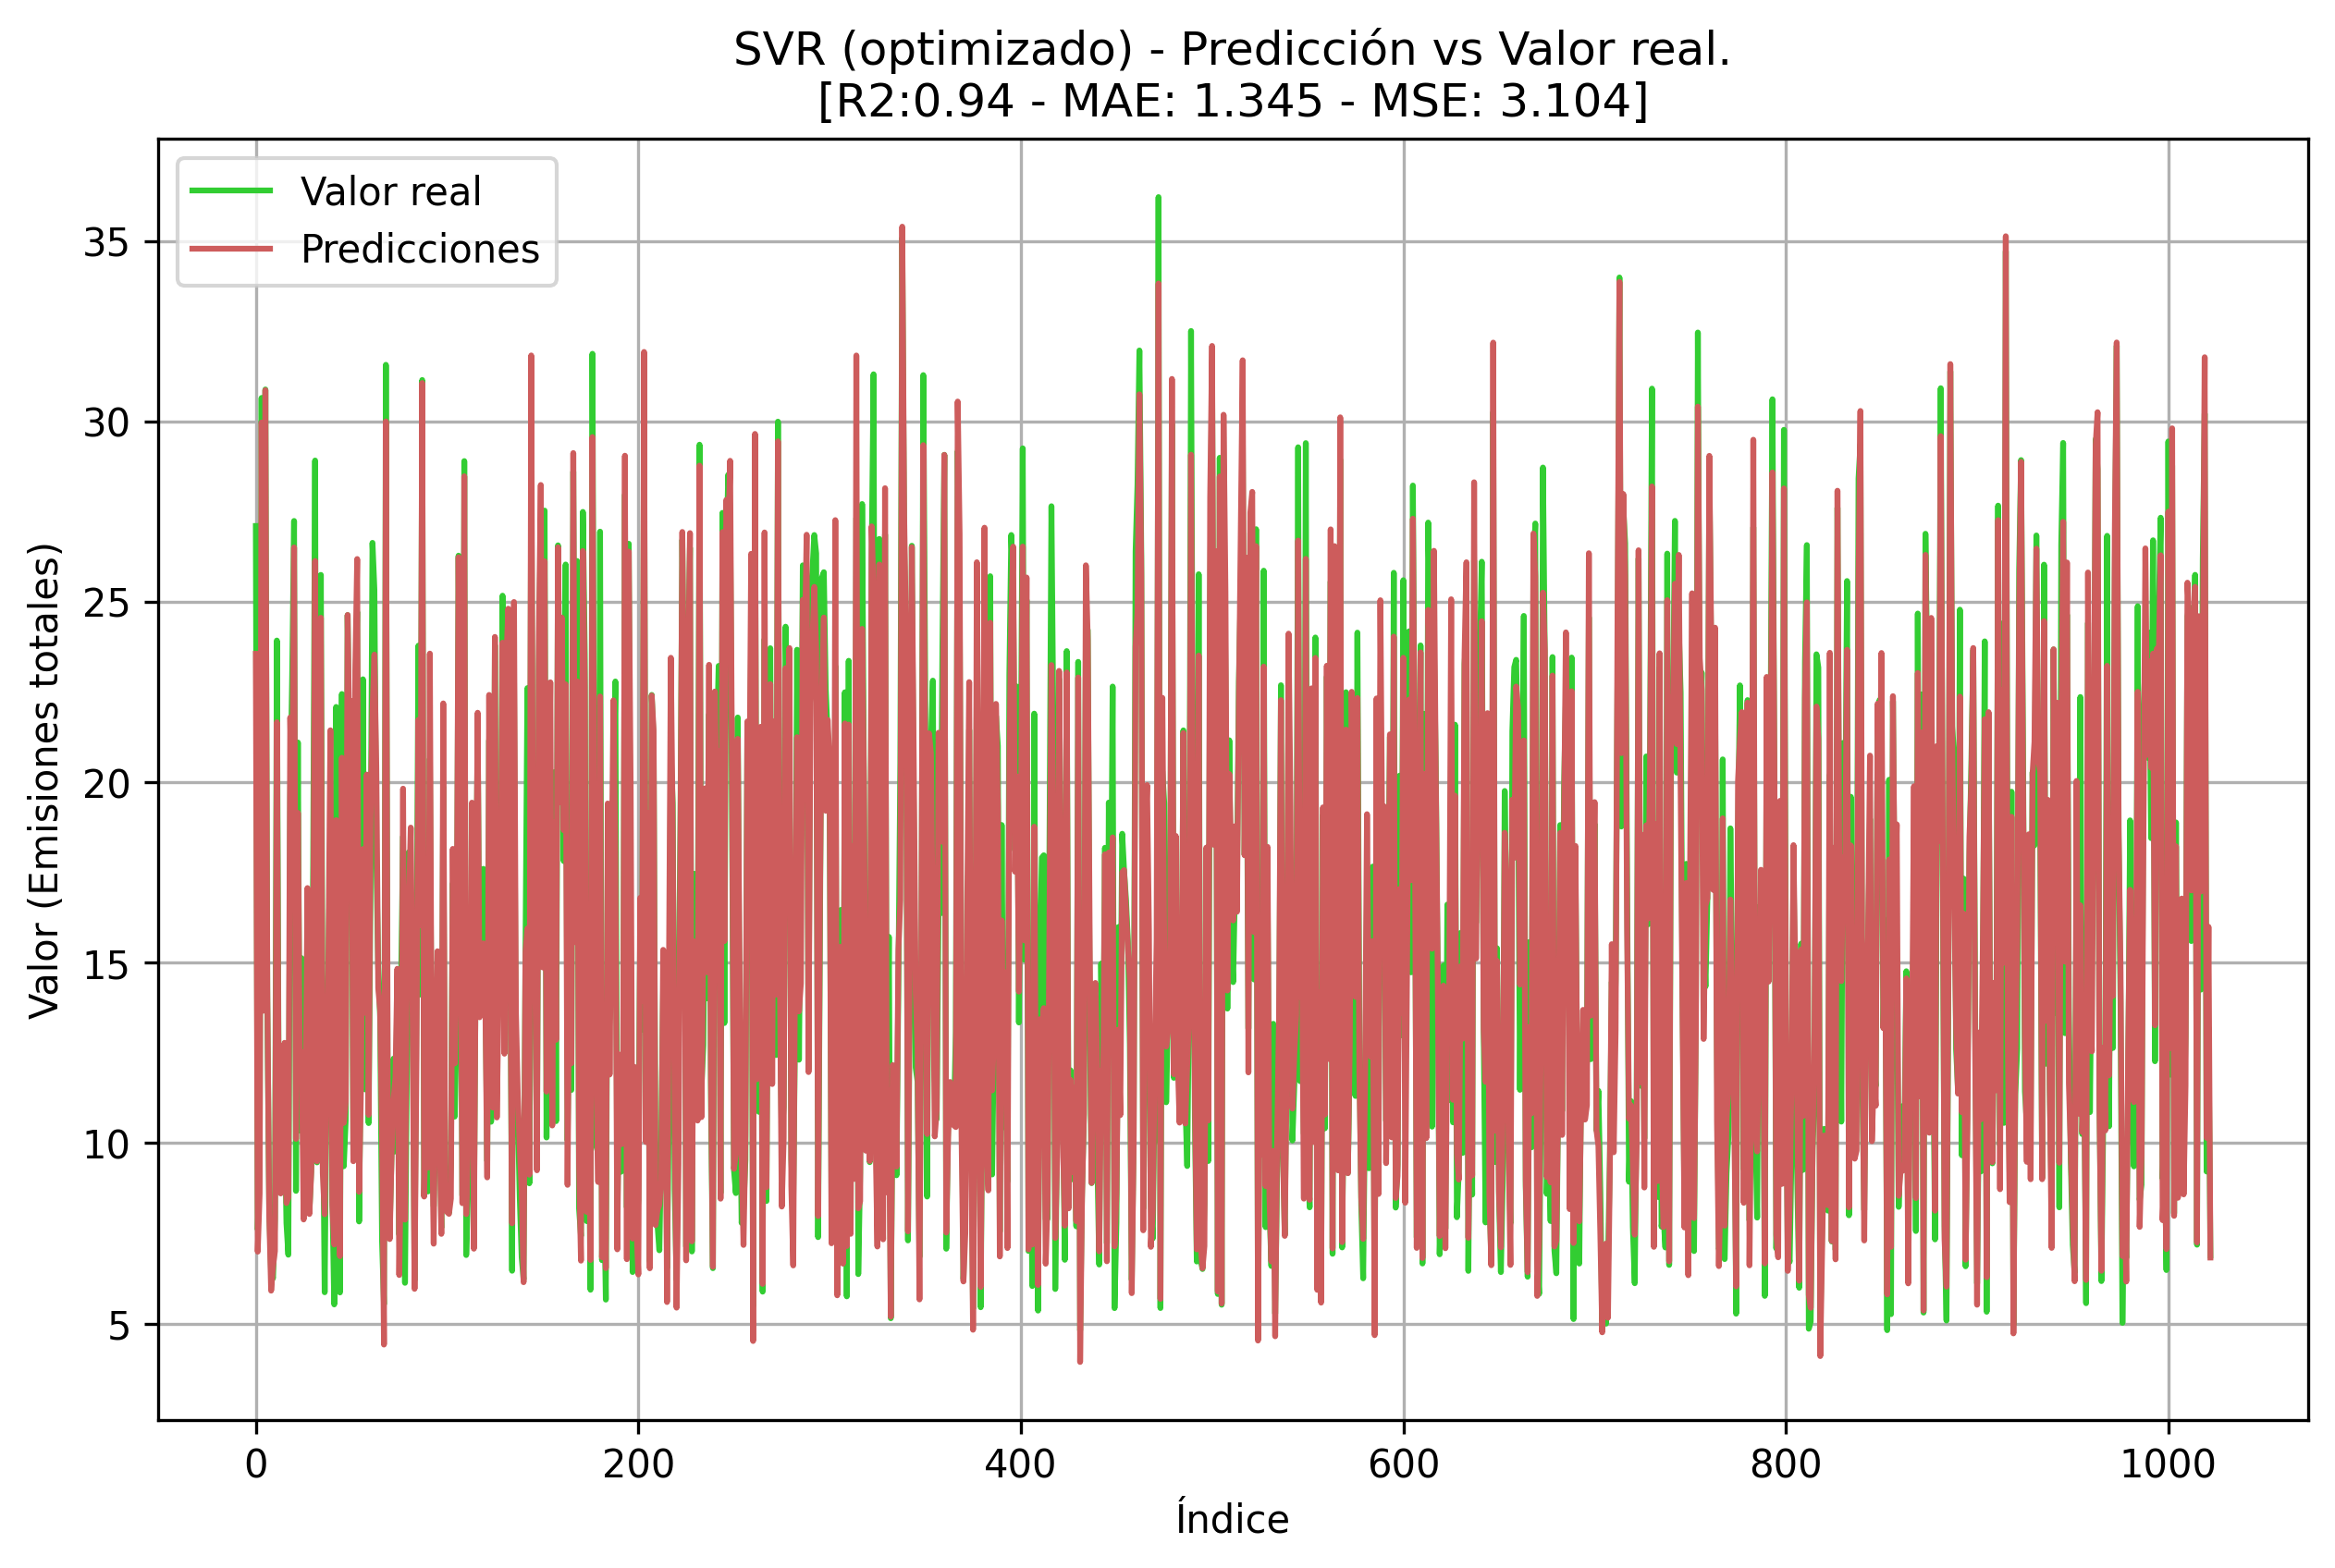

In [36]:

descripcion = f'SVR (optimizado) - Predicción vs Valor real.'
visualizarPrediccionesValorReal(Y_test, y_pred_svr, descripcion, MAE, MSE, R2)


## Tercer modelo: Red neuronal, Perceptrón multicapa (MLP)

In [38]:

# 1. Definición del modelo MLPRegressor (Parámetros por defecto)
modelo_RedNeuronal_MLP = MLPRegressor(max_iter=1000,
                                      random_state=seed_random_state )

# 2. Entrenamiento del modelo (Datos: X_train_norm)
modelo_RedNeuronal_MLP.fit(X_train_norm, np.ravel(Y_train))

# 3. Predicción del Porcentaje_Renovable (Datos: X_test_norm)
y_pred_rnMLP = modelo_RedNeuronal_MLP.predict(X_test_norm)

# 4. Cálculo de las métricas de evaluación (Y_test vs y_pred)
mae_rn_mlp = mean_absolute_error(Y_test, y_pred_rnMLP)
mse_rn_mlp = mean_squared_error(Y_test, y_pred_rnMLP)
r2_rn_mlp = r2_score(Y_test, y_pred_rnMLP)
print("Red neuronal MLP (no optimizado) - Métricas TEST:")
print(mae_rn_mlp, mse_rn_mlp, r2_rn_mlp)


Red neuronal MLP (no optimizado) - Métricas TEST:
1.470545112751829 3.569011871688953 0.9308303811028359


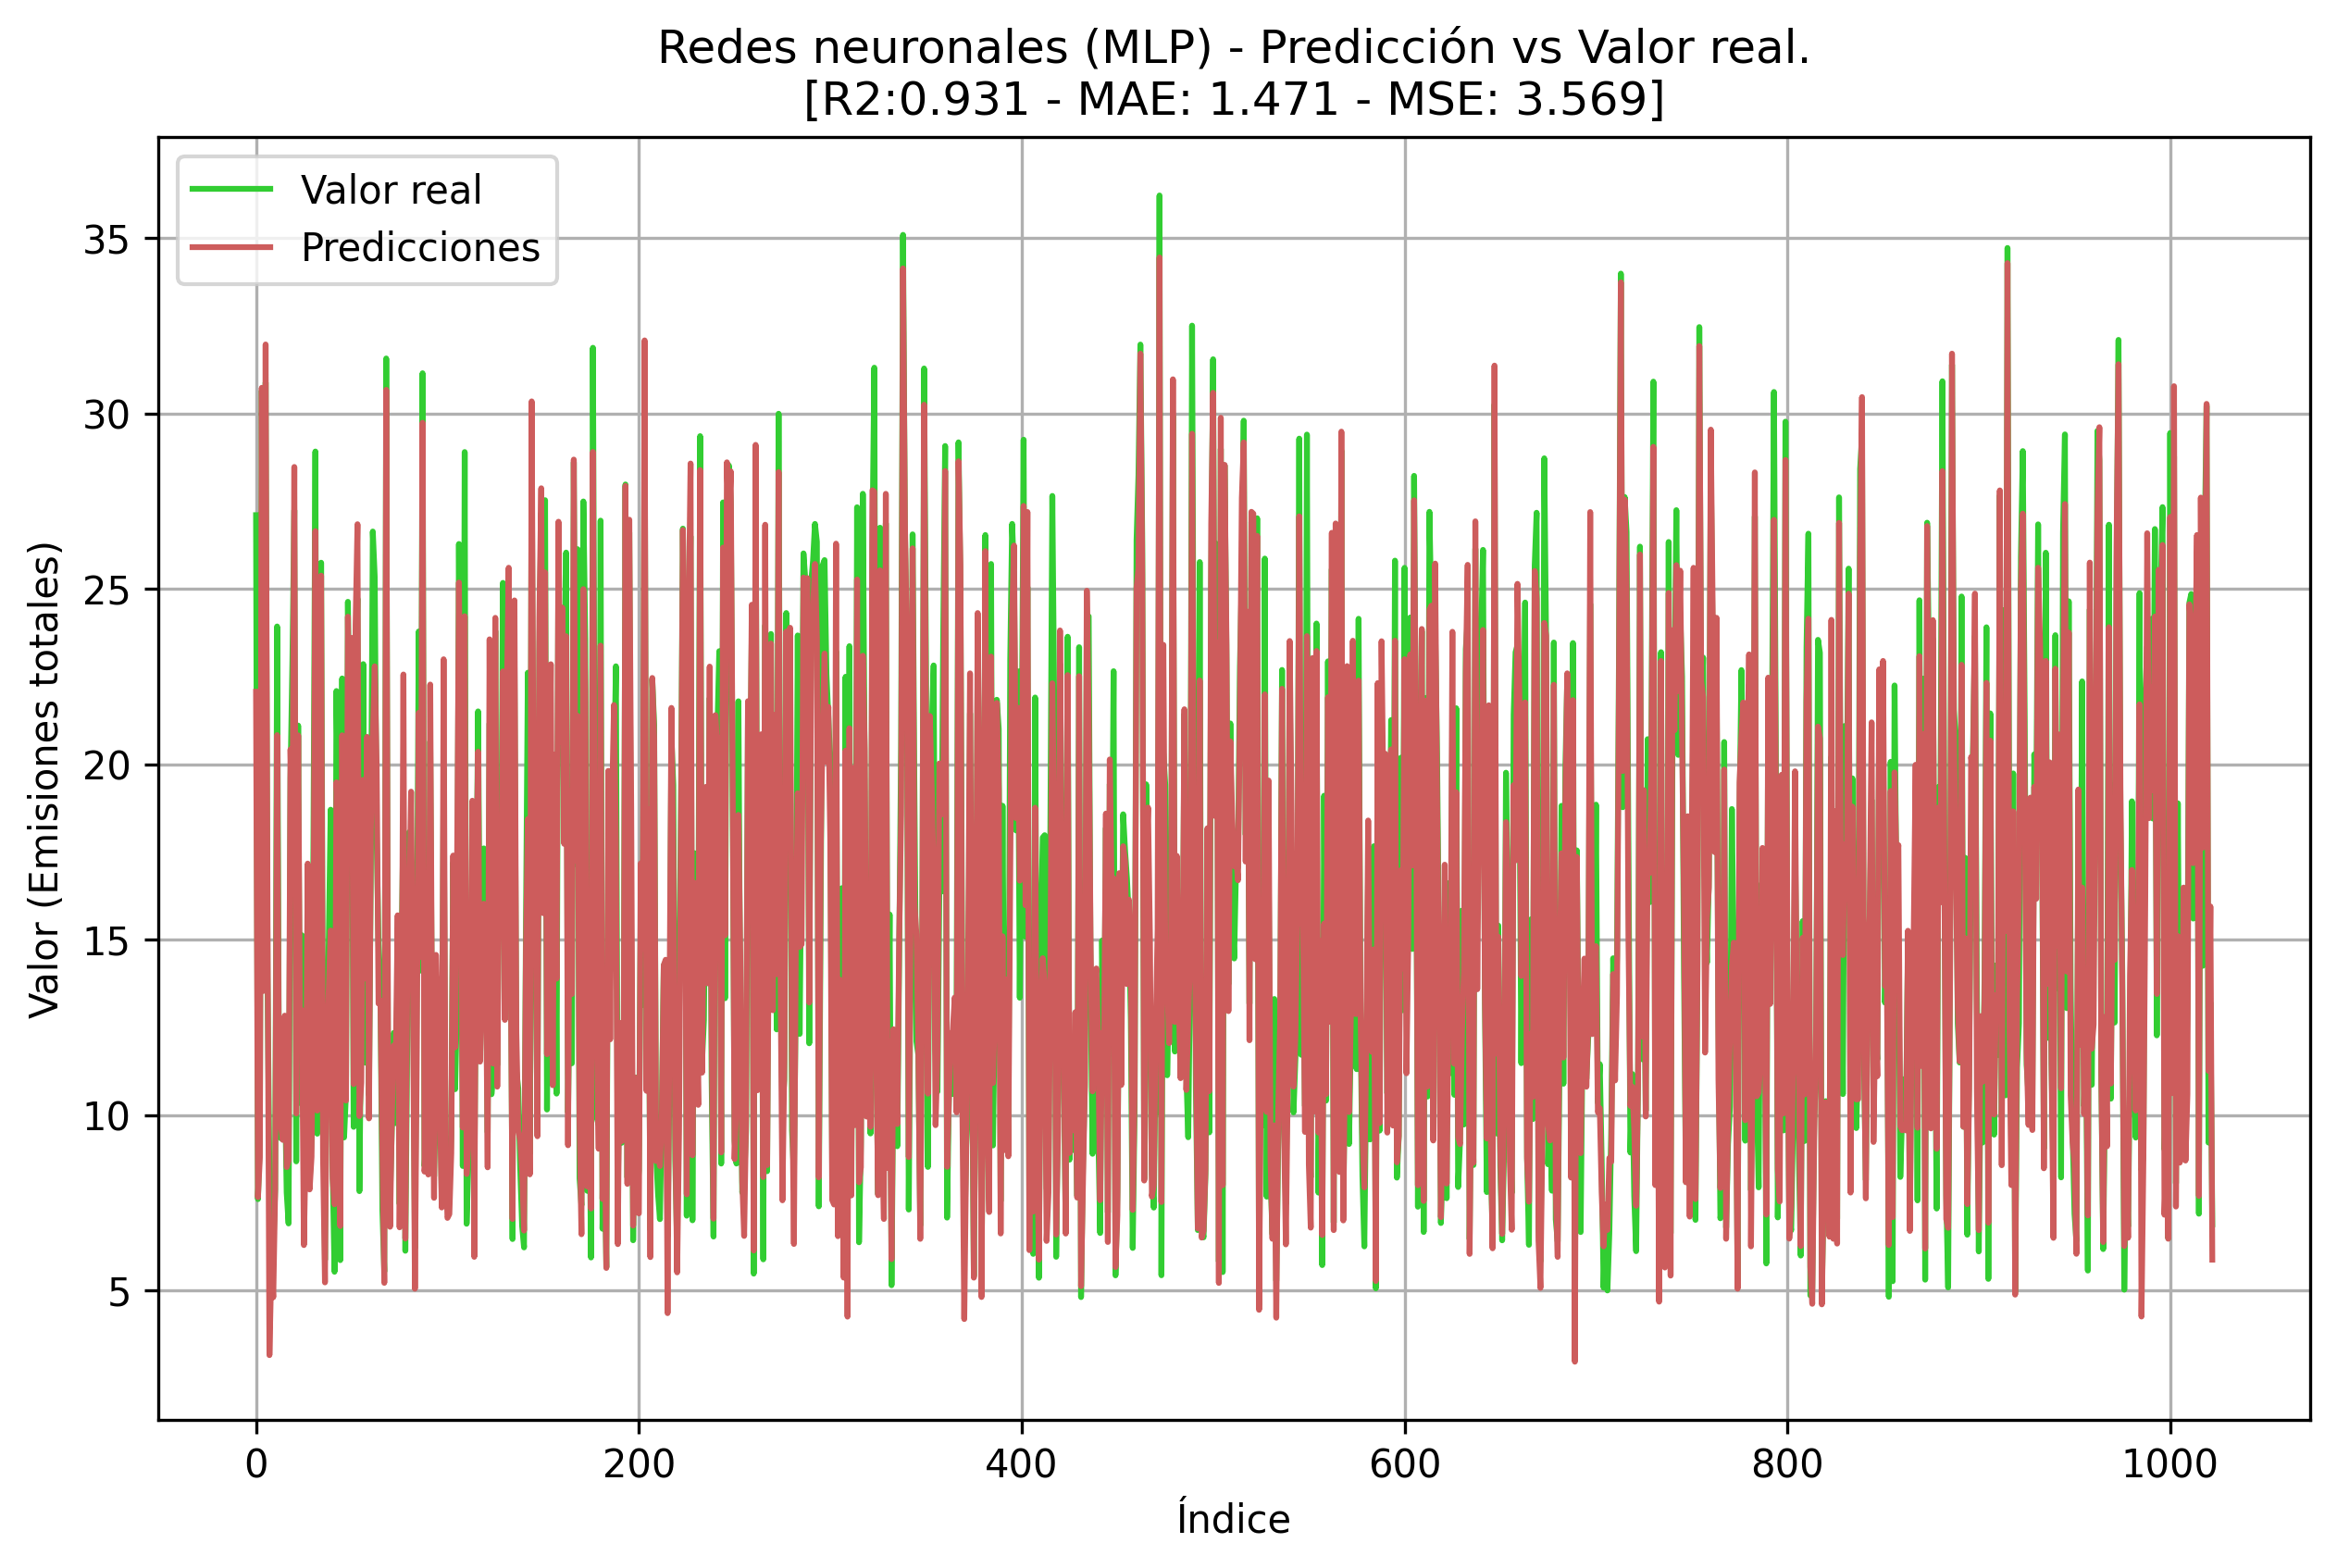

In [39]:
descripcion = f'Redes neuronales (MLP) - Predicción vs Valor real.'
visualizarPrediccionesValorReal(Y_test, y_pred_rnMLP, descripcion, mae_rn_mlp, mse_rn_mlp, r2_rn_mlp)

In [40]:


# 1. Parametrizar la búsqueda de RandomizedSearchCV
parametros_RSCV_rnMLP = {
    'hidden_layer_sizes': [(50,), (100,), (150,), (50, 50), (100, 50),
     (150, 100), (100, 100), (150, 100, 50)],
    'activation': ['tanh', 'relu'],
    'solver': ['sgd', 'adam', 'lbfgs'],
    'alpha': loguniform(1e-5, 1e-1),
    'learning_rate': ['constant', 'adaptive', 'invscaling'],
    'learning_rate_init': loguniform(1e-4, 1e-1)}

# 2. Validación cruzada para validación interna del algoritmo
cv = KFold(n_splits=5, shuffle=True, random_state=seed_random_state)

# 3. Configuración RandomizedSearchCV
randomizedSearch_rnMLP = RandomizedSearchCV(
    MLPRegressor(max_iter=1000, random_state=seed_random_state),
    param_distributions=parametros_RSCV_rnMLP,
    n_iter=50, cv=cv, # 50 iteraciones # Validación cruzada CV=5
    random_state=seed_random_state, n_jobs=-1)  # Trabajos en paralelo (todos los posibles)

# 4. Entrenamiento RandomizedSearchCV (Datos: X_train_norm)
randomizedSearch_rnMLP.fit(X_train_norm, np.ravel(Y_train))

# 5. Mejores parámetros de RandomizedSearchCV
mejoresParametros_RSCV_rnMLP = randomizedSearch_rnMLP.best_params_
print("Mejores parámetros encontrados por RandomizedSearchCV:", mejoresParametros_RSCV_rnMLP)

C:\Users\sergi\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
5 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\sergi\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\sergi\anaconda3\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\sergi\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py", line 751, in fit
 

Mejores parámetros encontrados por RandomizedSearchCV: {'activation': 'relu', 'alpha': 0.0966083798729217, 'hidden_layer_sizes': (150, 100), 'learning_rate': 'constant', 'learning_rate_init': 0.05026366723161423, 'solver': 'lbfgs'}


C:\Users\sergi\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:545: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [41]:
# 1. Parametrizar la búsqueda de GridSearchCV
parametros_GSCV_rnMLP = {
    'hidden_layer_sizes': [mejoresParametros_RSCV_rnMLP['hidden_layer_sizes'],
        (mejoresParametros_RSCV_rnMLP['hidden_layer_sizes'][0] + 10,)],
    'activation': [mejoresParametros_RSCV_rnMLP['activation']],
    'solver': [mejoresParametros_RSCV_rnMLP['solver']],
    'alpha': [mejoresParametros_RSCV_rnMLP['alpha'] * 0.8,
        mejoresParametros_RSCV_rnMLP['alpha'],
        mejoresParametros_RSCV_rnMLP['alpha'] * 1.2],
    'learning_rate': [mejoresParametros_RSCV_rnMLP['learning_rate']]}

# 2. Configuración GridSearchCV
gridSearch_rnMLP = GridSearchCV(
    MLPRegressor(max_iter=1000, random_state=seed_random_state),
    param_grid=parametros_GSCV_rnMLP,
    cv=cv, n_jobs=-1)

# 3. Entrenamiento  GridSearchCV
gridSearch_rnMLP.fit(X_train_norm, np.ravel(Y_train))

# 4. Mejores parámetros de GridSearchCV
mejoresParametros_GSCV_rnMLP = gridSearch_rnMLP.best_params_
print("Mejores parámetros encontrados por GridSearchCV:", mejoresParametros_GSCV_rnMLP)

Mejores parámetros encontrados por GridSearchCV: {'activation': 'relu', 'alpha': 0.0966083798729217, 'hidden_layer_sizes': (150, 100), 'learning_rate': 'constant', 'solver': 'lbfgs'}


C:\Users\sergi\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:545: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [42]:

# 1. Predicción utilizando el modelo optimizado por RandomizedSearch + GridSearch
y_pred_rnMLP_optimizado = gridSearch_rnMLP.best_estimator_.predict(X_test_norm)

# 2. Cálculo de métricas: MAE, MSE y R2
mae_rnMLP_optimizado = mean_absolute_error(Y_test, y_pred_rnMLP_optimizado)
mse_rnMLP_optimizado = mean_squared_error(Y_test, y_pred_rnMLP_optimizado)
r2_rnMLP_optimizado = r2_score(Y_test, y_pred_rnMLP_optimizado)
print("Red neuronal MLP (Optimizado) - Métricas TEST:")
print(mae_rnMLP_optimizado, mse_rnMLP_optimizado, r2_rnMLP_optimizado)


Red neuronal MLP (Optimizado) - Métricas TEST:
1.103116601074678 2.104403393118911 0.9592153834335523


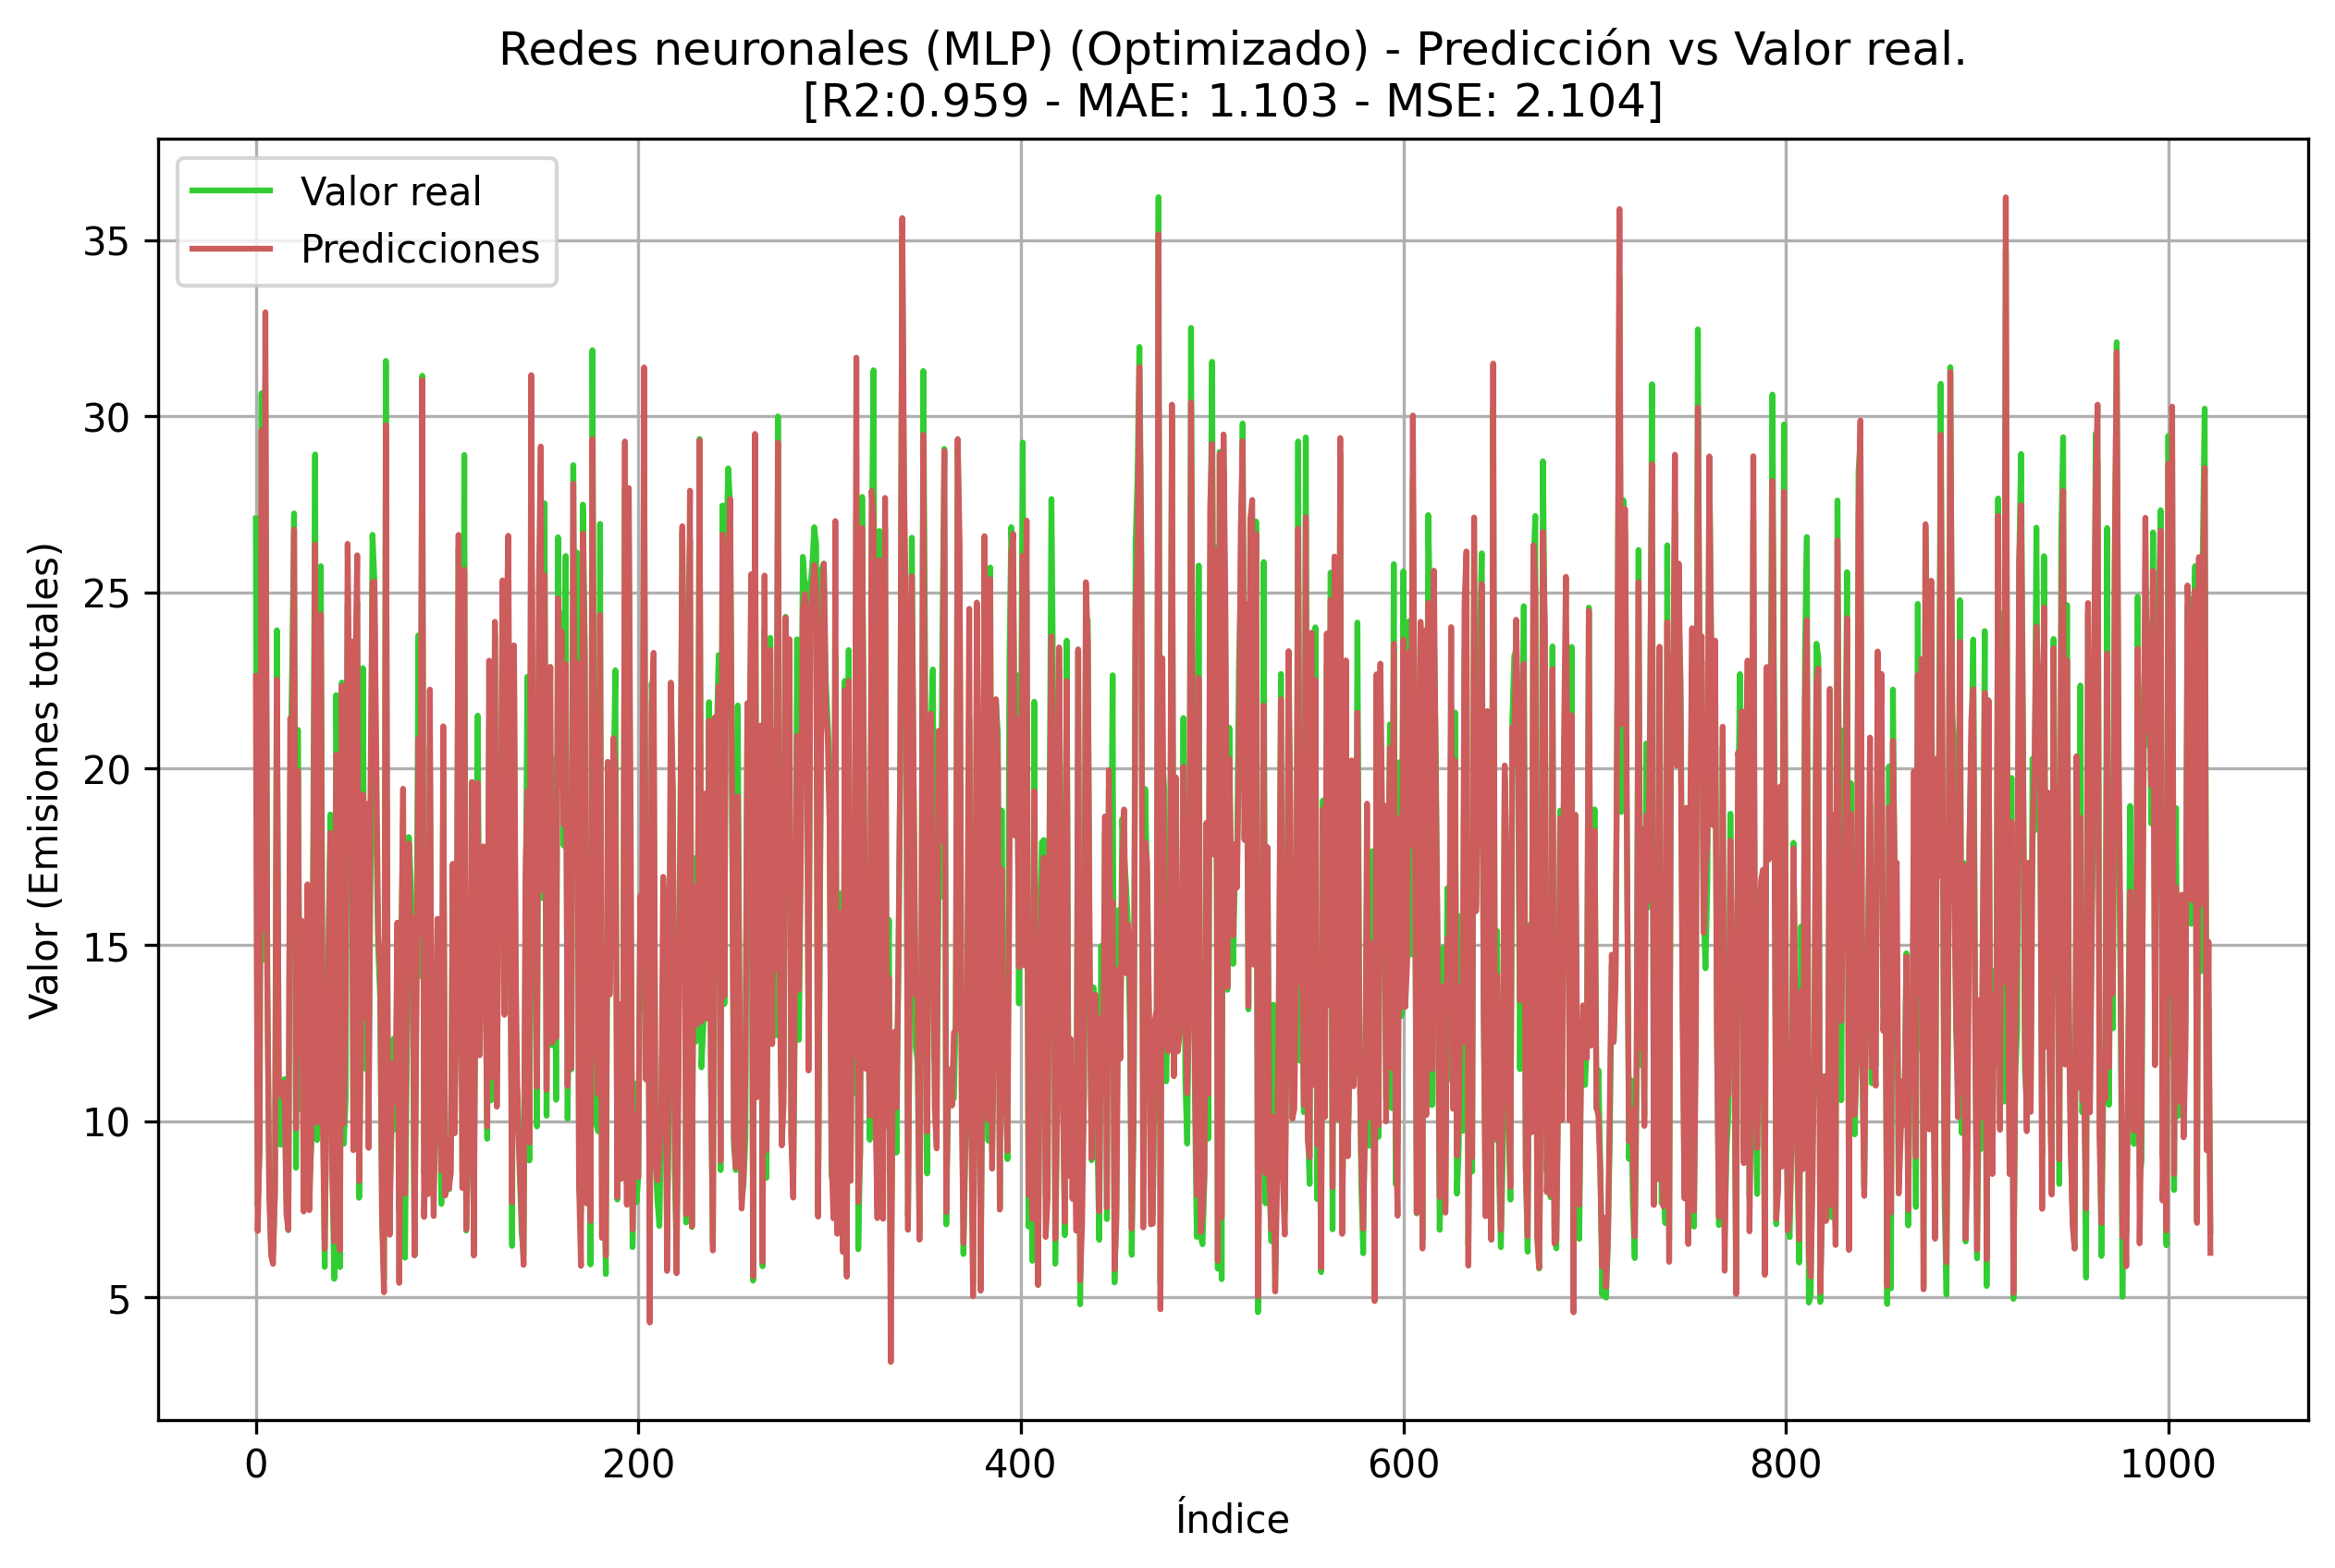

In [43]:
descripcion = f'Redes neuronales (MLP) (Optimizado) - Predicción vs Valor real.'
visualizarPrediccionesValorReal(Y_test, y_pred_rnMLP_optimizado, descripcion, mae_rnMLP_optimizado, mse_rnMLP_optimizado, r2_rnMLP_optimizado)
     

## Cuarto Modelo: Random Forest

In [45]:

# 1. Definición del modelo Random Forest (Parámetros por defecto)
randomForest_modelo = RandomForestRegressor(n_estimators=100,
                                            random_state=seed_random_state)

# 2. Entrenamiento del modelo (Datos: X_train_norm)
randomForest_modelo.fit(X_train_norm, np.ravel(Y_train))

# 3. Predicción del Porcentaje_Renovable (Datos: X_test_norm)
y_pred_randomforest = randomForest_modelo.predict(X_test_norm)

# 4. Cálculo de las métricas de evaluación (Y_test vs y_pred)
mae_rf = mean_absolute_error(Y_test, y_pred_randomforest)
mse_rf = mean_squared_error(Y_test, y_pred_randomforest)
r2_rf = r2_score(Y_test, y_pred_randomforest)
print("Random Forest (no optimizado) - Métricas TEST:")
print(mae_rf, mse_rf, r2_rf)

Random Forest (no optimizado) - Métricas TEST:
1.3137363716236559 3.0882276839511023 0.9401482708250329


In [46]:
print("Importancia de variables")
# Obtener la importancia de las características
importanciaCaracteristicas = randomForest_modelo.feature_importances_

# Crear un dataframe para visualizar mejor la importancia de las características
importanciaCaracteristicas = pd.DataFrame({
    'Variable': X.columns, 'Importancia': importanciaCaracteristicas})

# Ordenar el dataframe por la importancia
importanciaCaracteristicas = importanciaCaracteristicas.sort_values(by='Importancia', ascending=False)

# Mostrar la tabla de importancia de las características
print(importanciaCaracteristicas)

Importancia de variables
                    Variable  Importancia
0                        Año     0.461692
3  SumaGeneracion_Renovables     0.290930
4               valordemanda     0.191769
1                        Mes     0.013172
6           temperaturamedia     0.011393
9            presionminmedia     0.007748
7                 rachamedia     0.007269
8            humedadrelmedia     0.007081
5       precipitacionesmedia     0.005648
2                  DiaSemana     0.003299


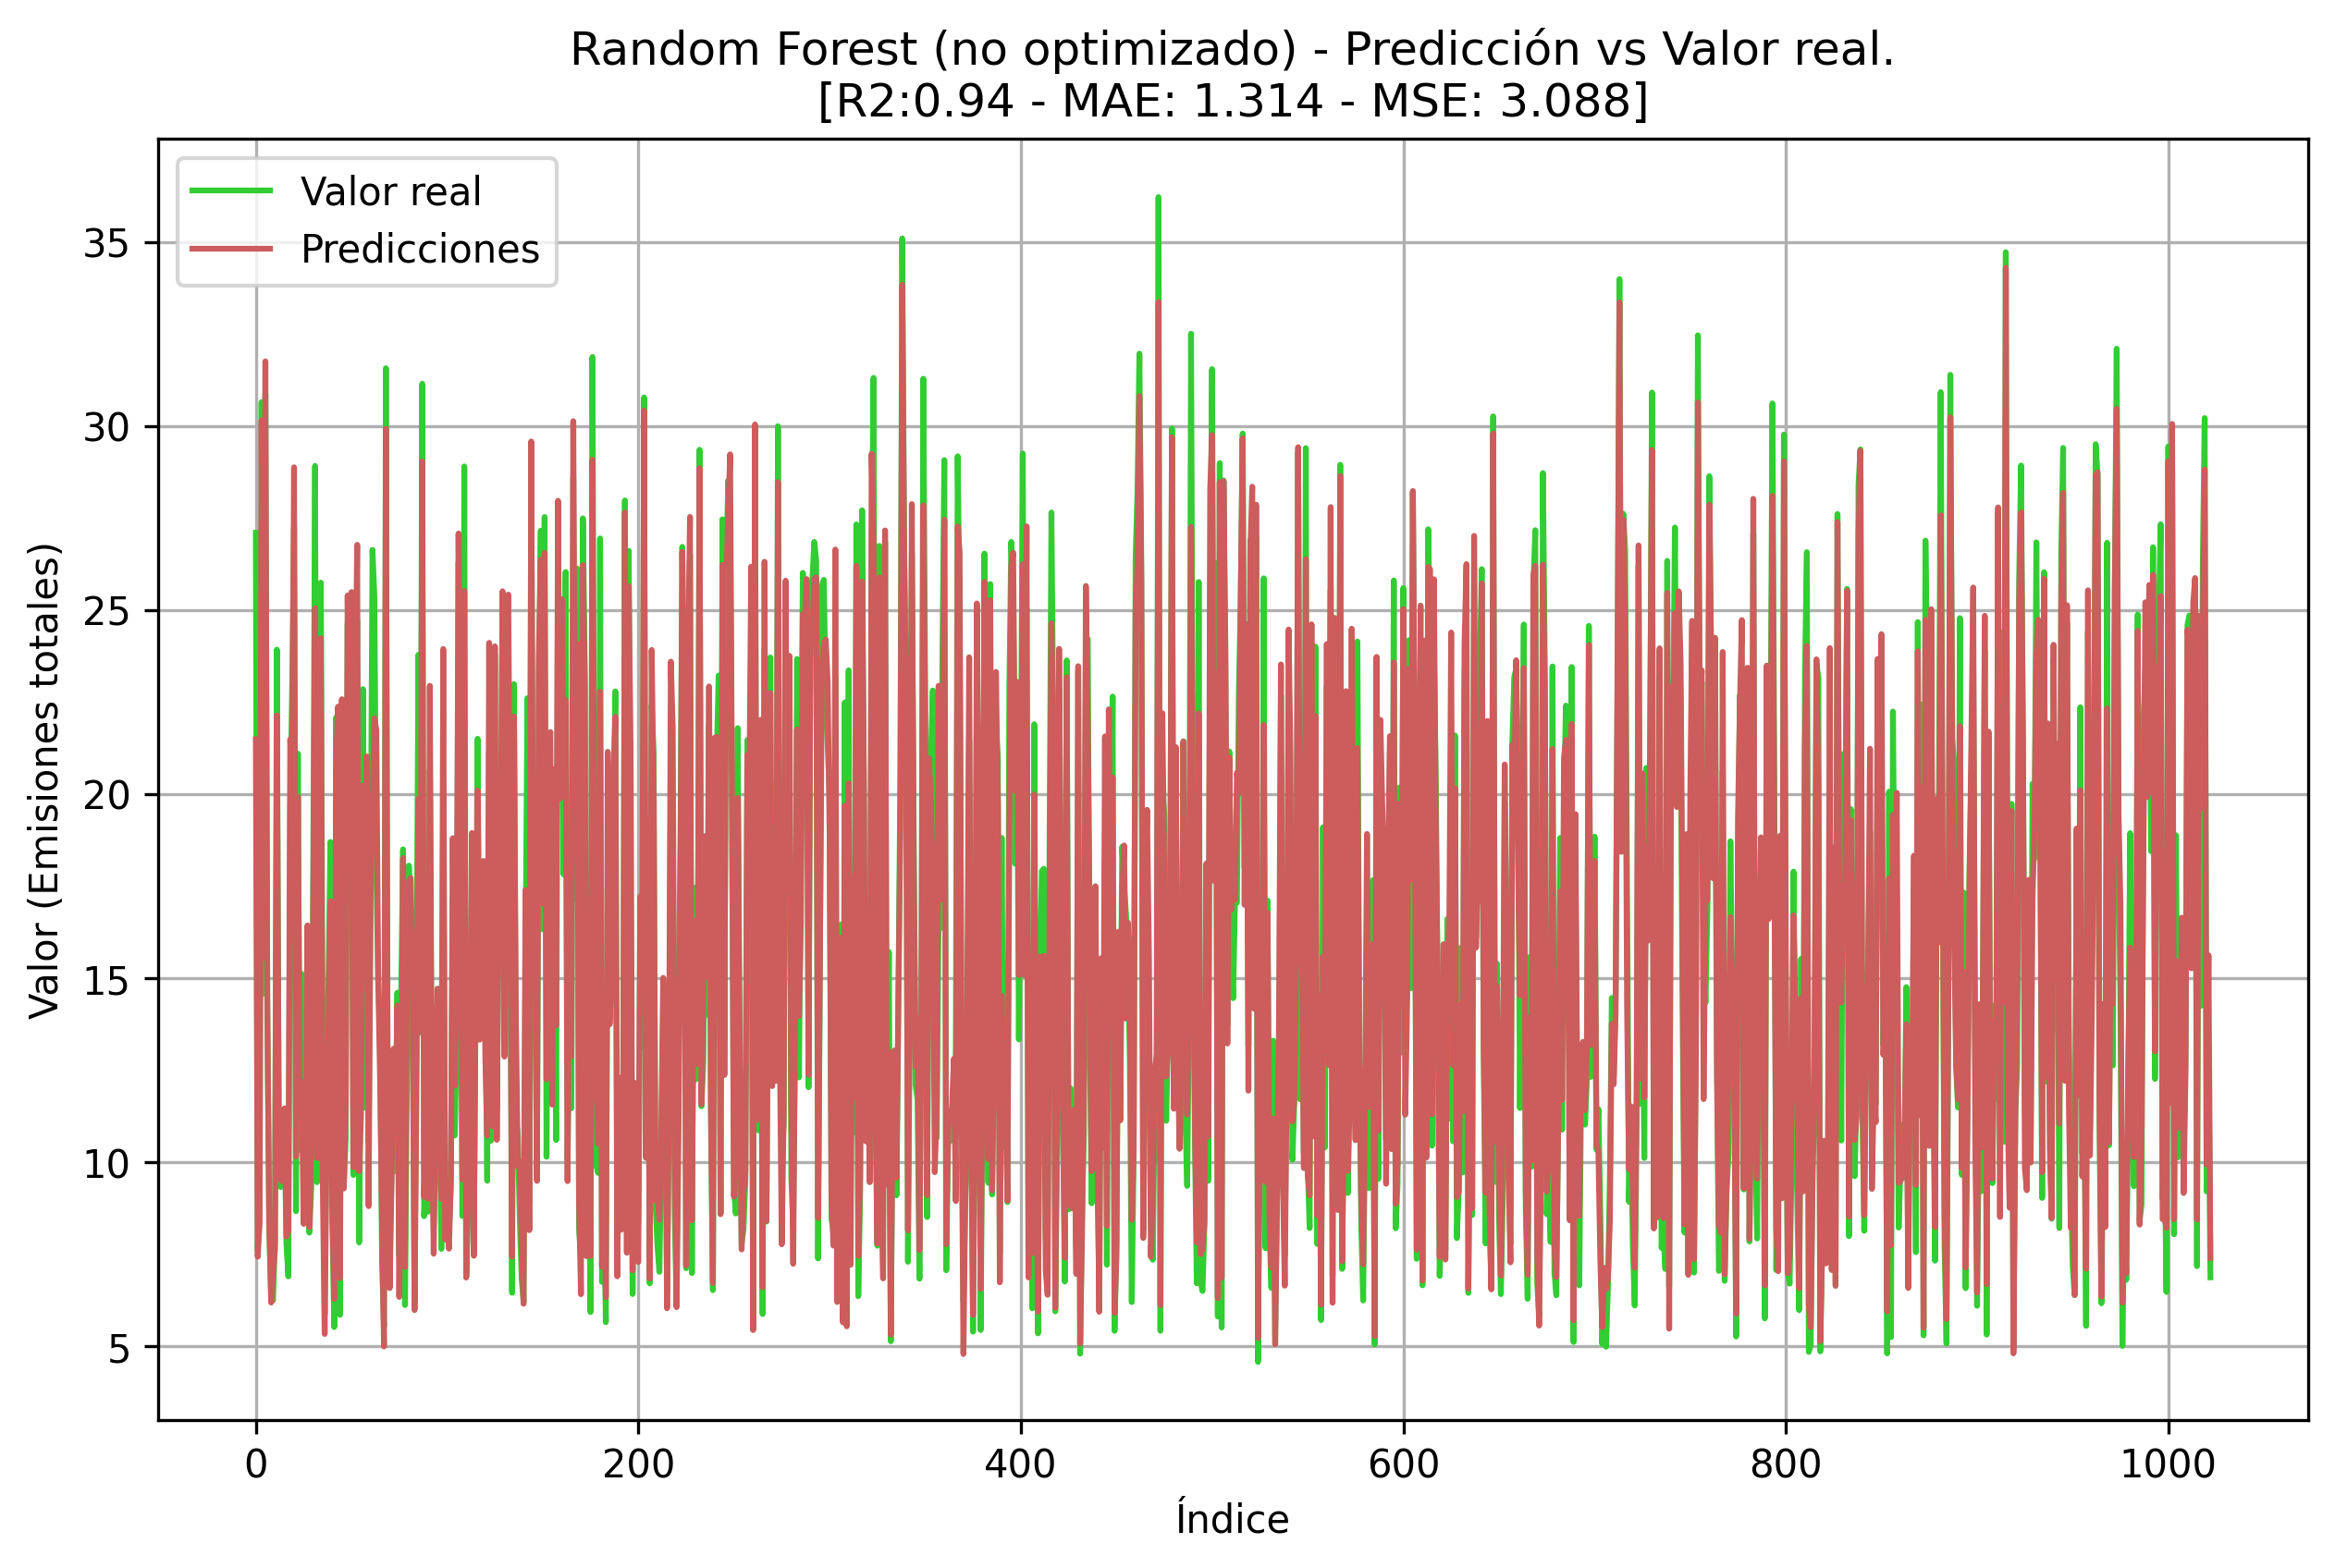

In [47]:
descripcion = f'Random Forest (no optimizado) - Predicción vs Valor real.'
visualizarPrediccionesValorReal(Y_test, y_pred_randomforest, descripcion, mae_rf, mse_rf, r2_rf)

In [48]:

# 1. Parametrizar la búsqueda de RandomizedSearchCV
parametros_RSCV_rf = {
    'n_estimators': randint(100, 1000),     # Núméro de árboles
    'max_depth': randint(10, 50),           # Profundidad máxima del árbol
    'min_samples_split': randint(2, 20),    # Muestras mínimas para división de un nodo
    'min_samples_leaf': randint(1, 10),     # Muertras mínimas por hoja
    'max_features': ['sqrt', 'log2', None], # Características para optimizar división
    'bootstrap': [True, False]  # False: se analiza todo el dataset en cada árbol
}

# 2. Validación cruzada para validación interna del algoritmo
cv = KFold(n_splits=5, shuffle=True, random_state=seed_random_state)

# 3. Configuración RandomizedSearchCV
randomizedSearch_rf = RandomizedSearchCV(
    estimator=RandomForestRegressor(n_estimators=100,
                                    random_state=seed_random_state),
    param_distributions=parametros_RSCV_rf,
    n_iter=100,   # 100 iteraciones
    cv=cv,        # Validación cruzada CV=5
    random_state=seed_random_state,
    n_jobs=-1)    # Trabajos en paralelo (todos los posibles)

# 4. Entrenamiento RandomizedSearchCV (Datos: X_train_norm)
randomizedSearch_rf.fit(X_train_norm, np.ravel(Y_train))

# 5. Mejores parámetros de RandomizedSearchCV
mejoresParametros_RSCV_rf = randomizedSearch_rf.best_params_
print("Mejores parámetros encontrados por RandomizedSearchCV:", mejoresParametros_RSCV_rf)

Mejores parámetros encontrados por RandomizedSearchCV: {'bootstrap': False, 'max_depth': 39, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 559}


In [49]:
# 5. Mejores parámetros de RandomizedSearchCV
mejoresParametros_RSCV_rf = randomizedSearch_rf.best_params_
print("Mejores parámetros encontrados por RandomizedSearchCV:", mejoresParametros_RSCV_rf)

Mejores parámetros encontrados por RandomizedSearchCV: {'bootstrap': False, 'max_depth': 39, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 559}


In [50]:
report(randomizedSearch_rf.cv_results_, n_top = 5)

Model with rank: 1
Mean validation score: 0.938 (std: 0.005)
Parameters: {'bootstrap': False, 'max_depth': 39, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 559}

Model with rank: 2
Mean validation score: 0.937 (std: 0.005)
Parameters: {'bootstrap': True, 'max_depth': 46, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 267}

Model with rank: 3
Mean validation score: 0.937 (std: 0.005)
Parameters: {'bootstrap': False, 'max_depth': 36, 'max_features': 'log2', 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 790}

Model with rank: 4
Mean validation score: 0.937 (std: 0.005)
Parameters: {'bootstrap': False, 'max_depth': 49, 'max_features': 'log2', 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 838}

Model with rank: 5
Mean validation score: 0.937 (std: 0.005)
Parameters: {'bootstrap': False, 'max_depth': 36, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 6, 'n_es

In [51]:

# 1. Parametrizar la búsqueda de GridSearchCV
parametrosGridSearch_rf = {
    'n_estimators': [max(mejoresParametros_RSCV_rf['n_estimators'] - 50, 100),
                     mejoresParametros_RSCV_rf['n_estimators'],
                     mejoresParametros_RSCV_rf['n_estimators'] + 50],
    'max_depth': [max(mejoresParametros_RSCV_rf['max_depth'] - 5, 10),
                  mejoresParametros_RSCV_rf['max_depth'],
                  mejoresParametros_RSCV_rf['max_depth'] + 5],
    'min_samples_split': [max(mejoresParametros_RSCV_rf['min_samples_split'] - 2, 2),
                          mejoresParametros_RSCV_rf['min_samples_split'],
                          mejoresParametros_RSCV_rf['min_samples_split'] + 2],
    'min_samples_leaf': [max(mejoresParametros_RSCV_rf['min_samples_leaf'] - 1, 1),
                         mejoresParametros_RSCV_rf['min_samples_leaf'],
                         mejoresParametros_RSCV_rf['min_samples_leaf'] + 1],
    'max_features': [mejoresParametros_RSCV_rf['max_features']],
    'bootstrap': [mejoresParametros_RSCV_rf['bootstrap']]}

# 2. Configuración GridSearchCV
gridSearch_randomForest = GridSearchCV(
    estimator=RandomForestRegressor(n_estimators=100, random_state=seed_random_state),
    param_grid=parametrosGridSearch_rf, cv=cv, n_jobs=-1)

# 3. Entrenamiento  GridSearchCV
gridSearch_randomForest.fit(X_train_norm, np.ravel(Y_train))

# 4. Mejores parámetros de GridSearchCV
mejoresParametros_GSCV_rf = gridSearch_randomForest.best_params_
print("Mejores parámetros encontrados por GridSearchCV:", mejoresParametros_GSCV_rf)

Mejores parámetros encontrados por GridSearchCV: {'bootstrap': False, 'max_depth': 39, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 559}


In [52]:
# 4. Mejores parámetros de GridSearchCV
mejoresParametros_GSCV_rf = gridSearch_randomForest.best_params_
print("Mejores parámetros encontrados por GridSearchCV:", mejoresParametros_GSCV_rf)

Mejores parámetros encontrados por GridSearchCV: {'bootstrap': False, 'max_depth': 39, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 559}


In [53]:
# 1. Predicción utilizando el modelo optimizado por RandomizedSearch + GridSearch
y_pred_rf_optimizado = gridSearch_randomForest.best_estimator_.predict(X_test_norm)

# 2. Cálculo de métricas: MAE, MSE y R2
mae_rf_optimizado = mean_absolute_error(Y_test, y_pred_rf_optimizado)
mse_rf_optimizado = mean_squared_error(Y_test, y_pred_rf_optimizado)
r2_rf_optimizado = r2_score(Y_test, y_pred_rf_optimizado)
print("Random Forest (Optimizado) - Métricas TEST:")
print(mae_rf_optimizado, mse_rf_optimizado, r2_rf_optimizado)

Random Forest (Optimizado) - Métricas TEST:
1.2659402459964646 2.864291161082794 0.9444882967203873


In [54]:
print("Importancia de variables\n")
# Crear un dataframe para visualizar mejor la importancia de las características
importanciaCaracteristicas_rf_optimizado = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': gridSearch_randomForest.best_estimator_.feature_importances_
})

# Ordenar el dataframe por la importancia
importanciaCaracteristicas_rf_optimizado = importanciaCaracteristicas_rf_optimizado.sort_values(by='Importancia', ascending=False)

# Mostrar la tabla de importancia de las características
print(importanciaCaracteristicas_rf_optimizado)

Importancia de variables

                    Variable  Importancia
0                        Año     0.348126
3  SumaGeneracion_Renovables     0.280710
4               valordemanda     0.172245
7                 rachamedia     0.045086
1                        Mes     0.043233
6           temperaturamedia     0.036747
2                  DiaSemana     0.029025
9            presionminmedia     0.018256
8            humedadrelmedia     0.013849
5       precipitacionesmedia     0.012724


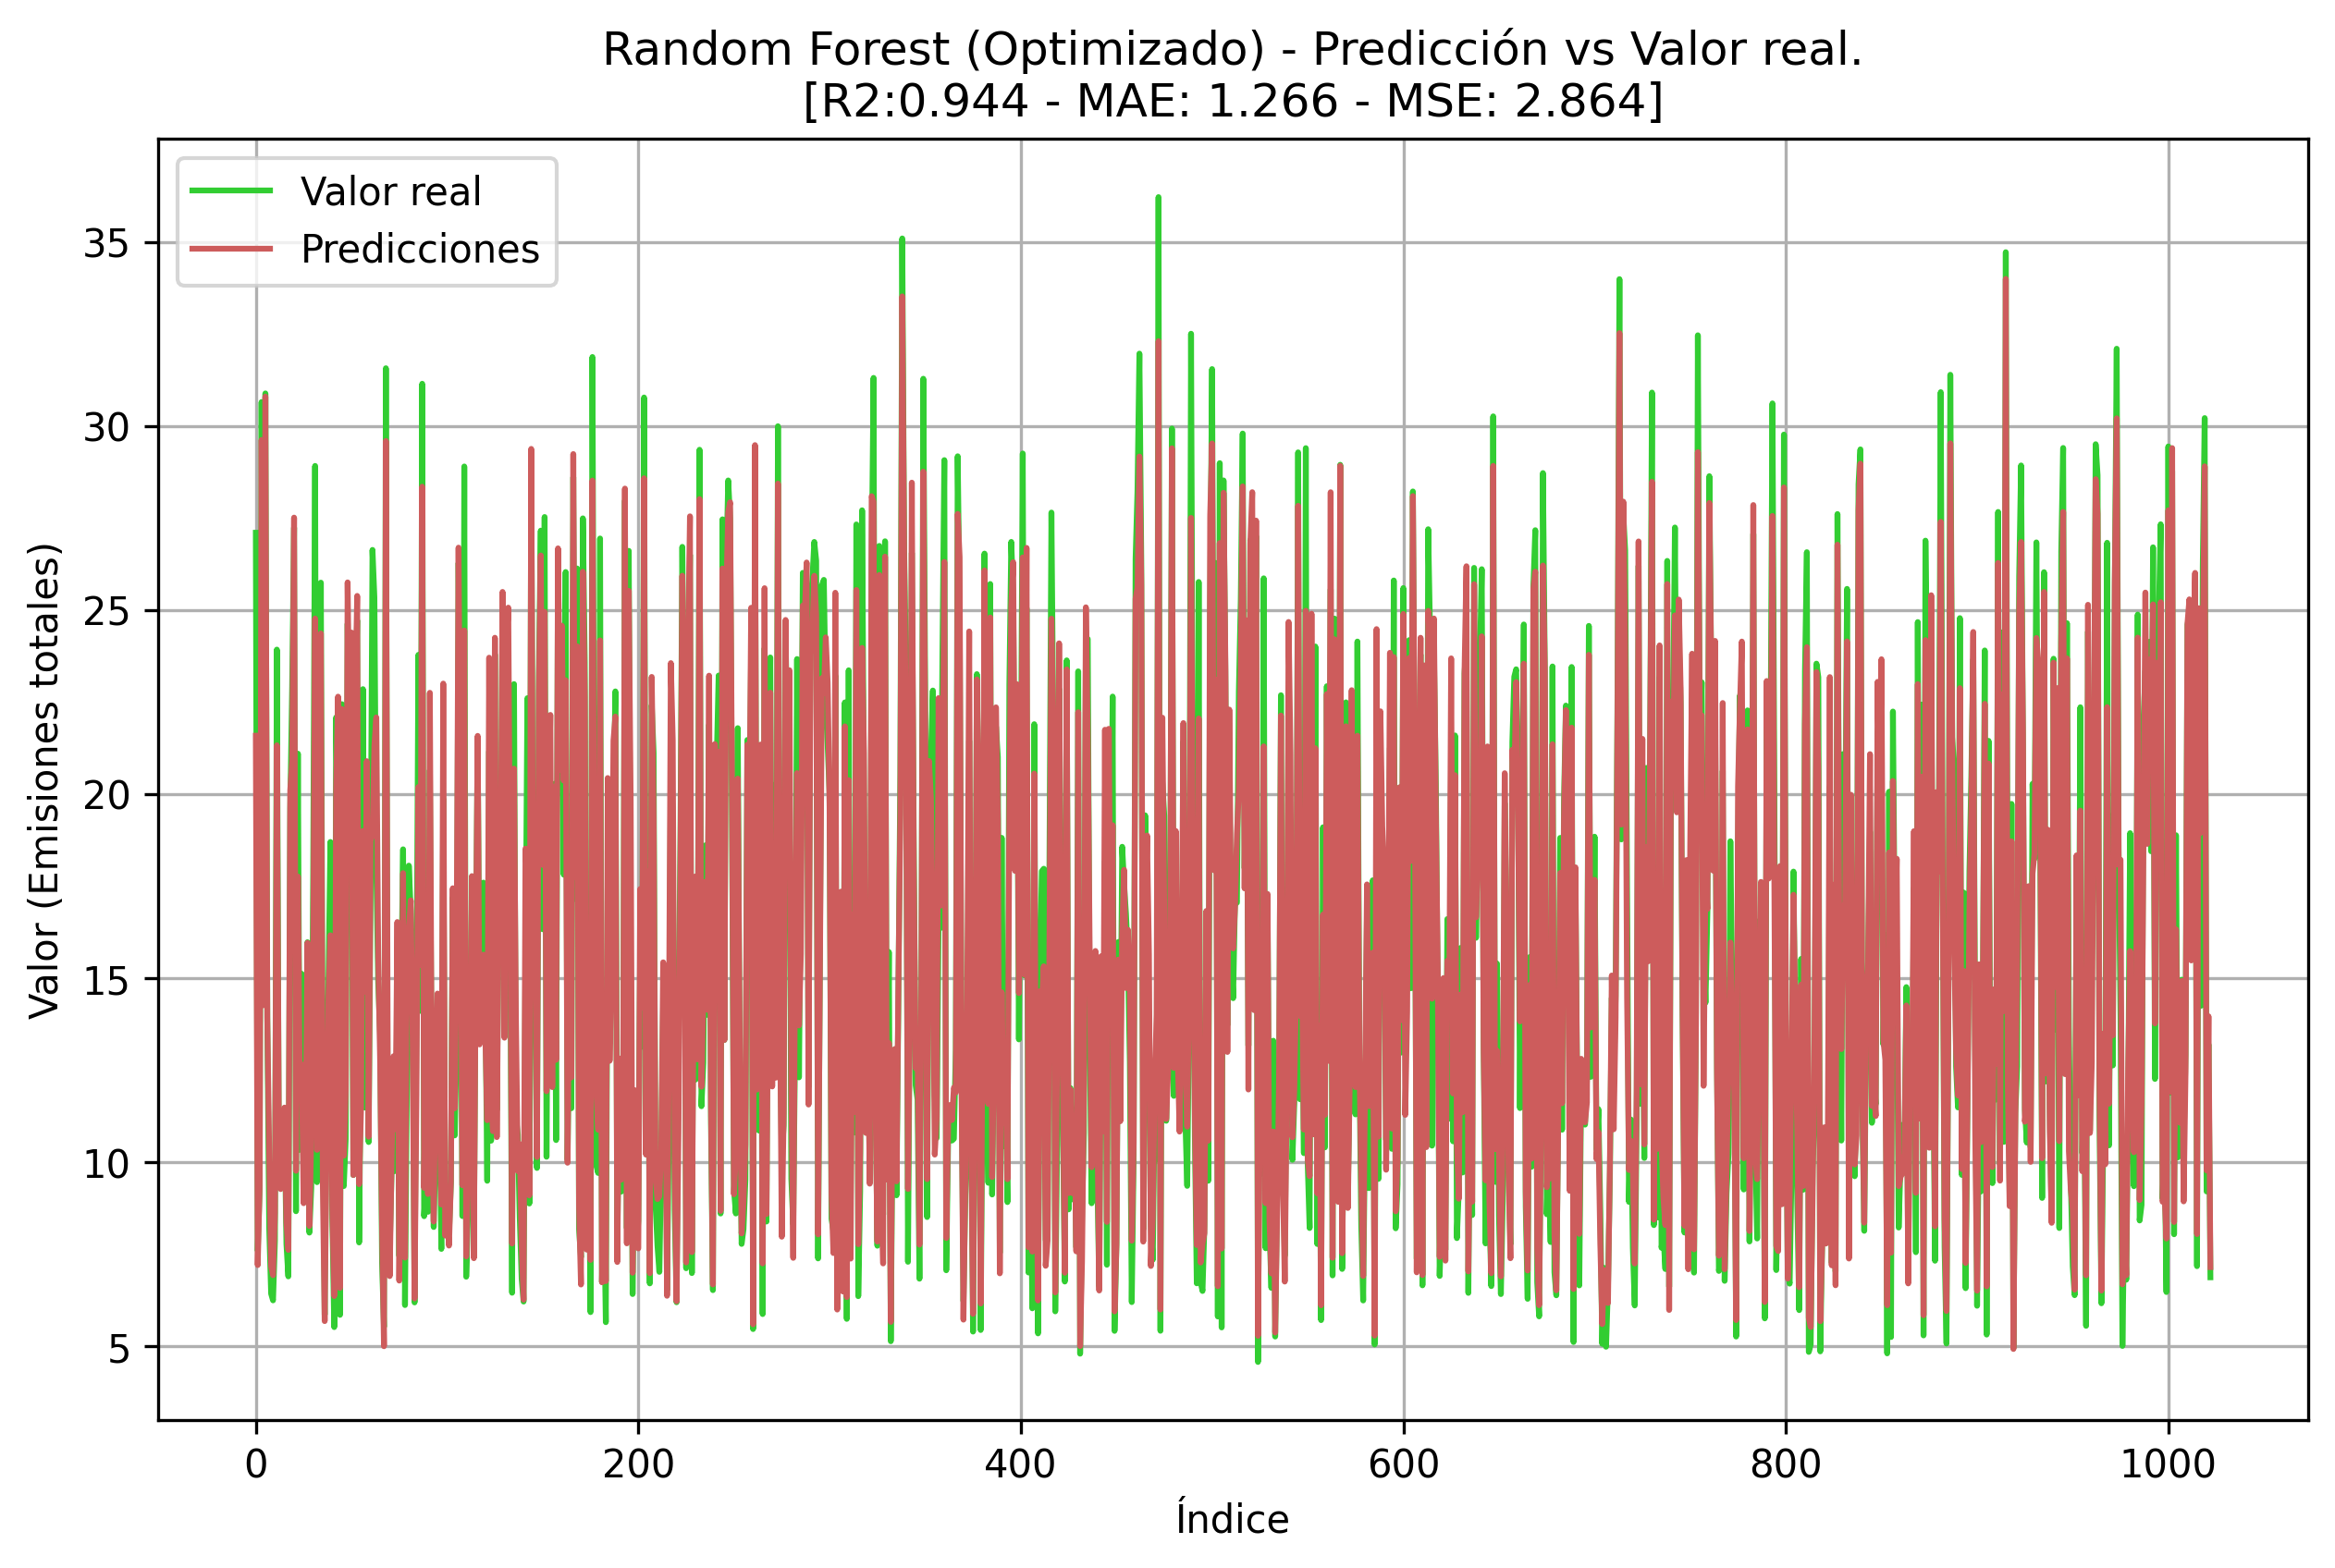

In [55]:
descripcion = f'Random Forest (Optimizado) - Predicción vs Valor real.'
visualizarPrediccionesValorReal(Y_test, y_pred_rf_optimizado, descripcion, mae_rf_optimizado, mse_rf_optimizado, r2_rf_optimizado)
     

## Quinto modelo: Gracient Boosting

In [57]:

# 1. Definición del modelo Gradient Boosting (Parámetros por defecto)
gradientboosting_modelo = GradientBoostingRegressor(n_estimators=100,
                                                    random_state=seed_random_state)

# 2. Entrenamiento del modelo (Datos: X_train_scaled)
gradientboosting_modelo.fit(X_train_norm, np.ravel(Y_train))

# 3. Predicción del Porcentaje_Renovable (Datos: X_test_scaled)
y_pred_gradientboosting = gradientboosting_modelo.predict(X_test_norm)

# 4. Cálculo de las métricas de evaluación (y_test vs y_pred)
mae_gb = mean_absolute_error(Y_test, y_pred_gradientboosting)
mse_gb = mean_squared_error(Y_test, y_pred_gradientboosting)
r2_gb = r2_score(Y_test, y_pred_gradientboosting)
print("Gradient Boosting (no optimizado) - Métricas TEST:")
print(mae_gb, mse_gb, r2_gb)

     

Gradient Boosting (no optimizado) - Métricas TEST:
1.3557421214087055 3.2963459567057476 0.9361148122293454


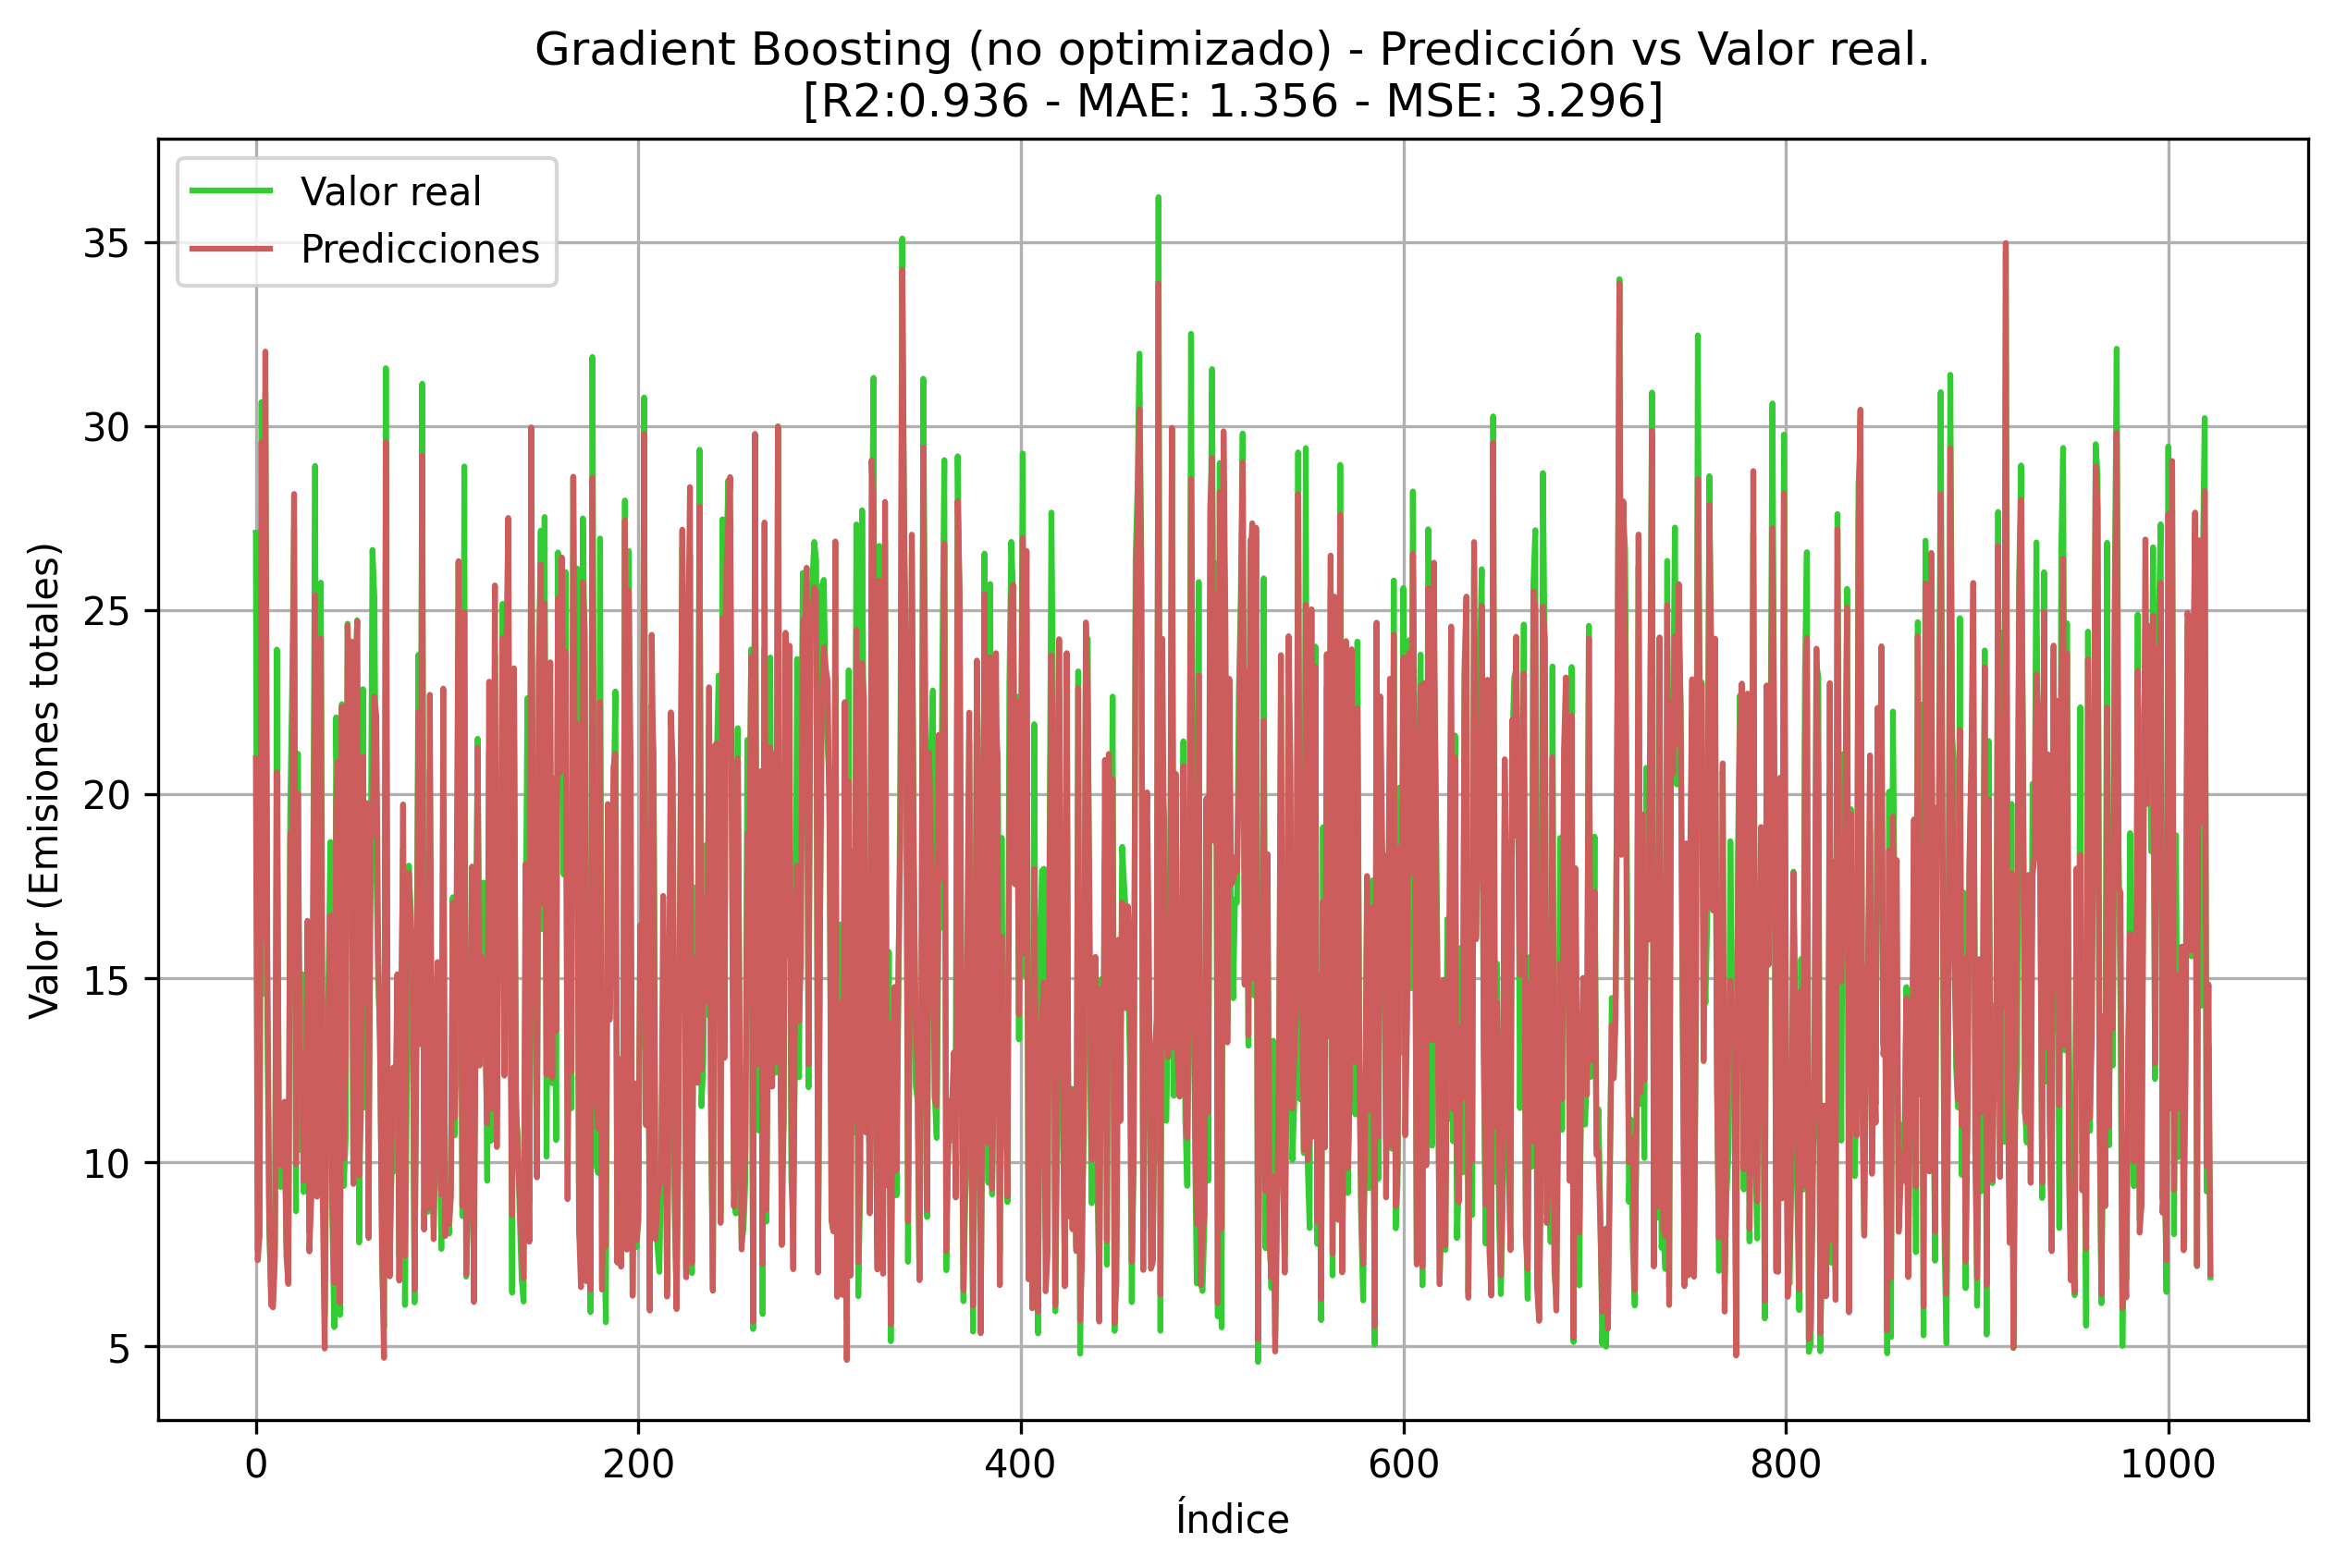

In [58]:
descripcion = f'Gradient Boosting (no optimizado) - Predicción vs Valor real.'
visualizarPrediccionesValorReal(Y_test, y_pred_gradientboosting, descripcion, mae_gb, mse_gb, r2_gb)

In [59]:

# 1. Parametrizar la búsqueda de RandomizedSearchCV
parametros_RSCV_gb = {
    'n_estimators': randint(50, 500),       # Núméro de árboles
    'max_depth': randint(3, 15),            # Profundidad máxima del árbol
    'min_samples_split': randint(2, 20),    # Muestras mínimas para división de un nodo
    'min_samples_leaf': randint(1, 10),     # Muestras mínimas por hoja
    'max_features': [None, 'sqrt', 'log2'], # Características para optimizar división
    'subsample': uniform(0.5, 0.5),         # Porcentaje de muestras entrenamiento árboles
    'learning_rate': uniform(0.01, 0.5)     # Tasa de aprendizaje
}

# 2. Validación cruzada para validación interna del algoritmo
cv = KFold(n_splits=5, shuffle=True, random_state=seed_random_state)

# 3. Configuración RandomizedSearchCV
randomizedSearch_gb = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(n_estimators=100, random_state=seed_random_state),
    param_distributions=parametros_RSCV_gb, n_iter=100,   # 100 iteraciones
    cv=cv,        # Validación cruzada CV=5
    random_state=seed_random_state, n_jobs=-1)    # Trabajos en paralelo (todos los posibles)

# 4. Entrenamiento RandomizedSearchCV (Datos: X_train_norm)
randomizedSearch_gb.fit(X_train_norm, np.ravel(Y_train))

# 5. Mejores parámetros de RandomizedSearchCV
mejoresParametros_RSCV_gb = randomizedSearch_gb.best_params_
print("Mejores parámetros encontrados por RandomizedSearchCV:", mejoresParametros_RSCV_gb)

Mejores parámetros encontrados por RandomizedSearchCV: {'learning_rate': 0.07659256261187485, 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 6, 'min_samples_split': 19, 'n_estimators': 420, 'subsample': 0.86285975419418}


In [60]:
report(randomizedSearch_gb.cv_results_, n_top = 5)

Model with rank: 1
Mean validation score: 0.955 (std: 0.004)
Parameters: {'learning_rate': 0.07659256261187485, 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 6, 'min_samples_split': 19, 'n_estimators': 420, 'subsample': 0.86285975419418}

Model with rank: 2
Mean validation score: 0.954 (std: 0.004)
Parameters: {'learning_rate': 0.05424625102595975, 'max_depth': 9, 'max_features': None, 'min_samples_leaf': 8, 'min_samples_split': 17, 'n_estimators': 286, 'subsample': 0.6356745158869479}

Model with rank: 3
Mean validation score: 0.952 (std: 0.003)
Parameters: {'learning_rate': 0.07425017661695509, 'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 5, 'min_samples_split': 13, 'n_estimators': 372, 'subsample': 0.910213421885634}

Model with rank: 4
Mean validation score: 0.952 (std: 0.005)
Parameters: {'learning_rate': 0.12978094533348622, 'max_depth': 4, 'max_features': None, 'min_samples_leaf': 6, 'min_samples_split': 5, 'n_estimators': 488, 'subsample': 0.880809807

In [61]:
# 1. Parametrizar la búsqueda de GridSearchCV
parametrosGridSearch_gb = {
    'n_estimators': [max(mejoresParametros_RSCV_gb['n_estimators'] - 50, 50),
                     mejoresParametros_RSCV_gb['n_estimators'],
                     mejoresParametros_RSCV_gb['n_estimators'] + 50],
    'learning_rate': [max(mejoresParametros_RSCV_gb['learning_rate'] - 0.05, 0.01),
                      mejoresParametros_RSCV_gb['learning_rate'],
                      min(mejoresParametros_RSCV_gb['learning_rate'] + 0.05, 1.0)],
    'max_depth': [max(mejoresParametros_RSCV_gb['max_depth'] - 2, 1),
                  mejoresParametros_RSCV_gb['max_depth'],
                  mejoresParametros_RSCV_gb['max_depth'] + 2],
    'min_samples_split': [max(mejoresParametros_RSCV_gb['min_samples_split'] - 2, 2),
                          mejoresParametros_RSCV_gb['min_samples_split'],
                          mejoresParametros_RSCV_gb['min_samples_split'] + 2],
    'min_samples_leaf': [max(mejoresParametros_RSCV_gb['min_samples_leaf'] - 1, 1),
                         mejoresParametros_RSCV_gb['min_samples_leaf'],
                         mejoresParametros_RSCV_gb['min_samples_leaf'] + 1],
    'subsample': [max(mejoresParametros_RSCV_gb['subsample'] - 0.1, 0.5),
                  mejoresParametros_RSCV_gb['subsample'],
                  min(mejoresParametros_RSCV_gb['subsample'] + 0.1, 1.0)],
    'max_features': [mejoresParametros_RSCV_gb['max_features']]}

# 2. Configuración GridSearchCV
gridSearch_gradientBoosting = GridSearchCV(estimator=GradientBoostingRegressor(n_estimators=100,
  random_state=seed_random_state), param_grid=parametrosGridSearch_gb, cv=cv, n_jobs=-1)

# 3. Entrenamiento  GridSearchCV
gridSearch_gradientBoosting.fit(X_train_norm, np.ravel(Y_train))

# 4. Mejores parámetros de GridSearchCV
mejoresParametros_GSCV_gb = gridSearch_gradientBoosting.best_params_
print("Mejores parámetros encontrados por GridSearchCV:", mejoresParametros_GSCV_gb)

Mejores parámetros encontrados por GridSearchCV: {'learning_rate': 0.026592562611874843, 'max_depth': 7, 'max_features': None, 'min_samples_leaf': 6, 'min_samples_split': 21, 'n_estimators': 470, 'subsample': 0.7628597541941801}


In [62]:
report(gridSearch_gradientBoosting.cv_results_, n_top = 5)

Model with rank: 1
Mean validation score: 0.956 (std: 0.004)
Parameters: {'learning_rate': 0.026592562611874843, 'max_depth': 7, 'max_features': None, 'min_samples_leaf': 6, 'min_samples_split': 21, 'n_estimators': 470, 'subsample': 0.7628597541941801}

Model with rank: 2
Mean validation score: 0.956 (std: 0.004)
Parameters: {'learning_rate': 0.026592562611874843, 'max_depth': 7, 'max_features': None, 'min_samples_leaf': 6, 'min_samples_split': 19, 'n_estimators': 470, 'subsample': 0.7628597541941801}

Model with rank: 3
Mean validation score: 0.956 (std: 0.004)
Parameters: {'learning_rate': 0.026592562611874843, 'max_depth': 7, 'max_features': None, 'min_samples_leaf': 7, 'min_samples_split': 19, 'n_estimators': 470, 'subsample': 0.7628597541941801}

Model with rank: 4
Mean validation score: 0.956 (std: 0.004)
Parameters: {'learning_rate': 0.026592562611874843, 'max_depth': 7, 'max_features': None, 'min_samples_leaf': 6, 'min_samples_split': 21, 'n_estimators': 420, 'subsample': 0.762

In [63]:
# 1. Predicción utilizando el modelo optimizado por RandomizedSearch + GridSearch
y_pred_gb_optimizado = gridSearch_gradientBoosting.best_estimator_.predict(X_test_norm)

# 2. Cálculo de métricas: MAE, MSE y R2
mae_gb_optimizado = mean_absolute_error(Y_test, y_pred_gb_optimizado)
mse_gb_optimizado = mean_squared_error(Y_test, y_pred_gb_optimizado)
r2_gb_optimizado = r2_score(Y_test, y_pred_gb_optimizado)
print("Gradient Boosting (Optimizado) - Métricas TEST:")
print(mae_gb_optimizado, mse_gb_optimizado, r2_gb_optimizado)

Gradient Boosting (Optimizado) - Métricas TEST:
1.0821865408040938 2.0968257262919883 0.9593622432214688


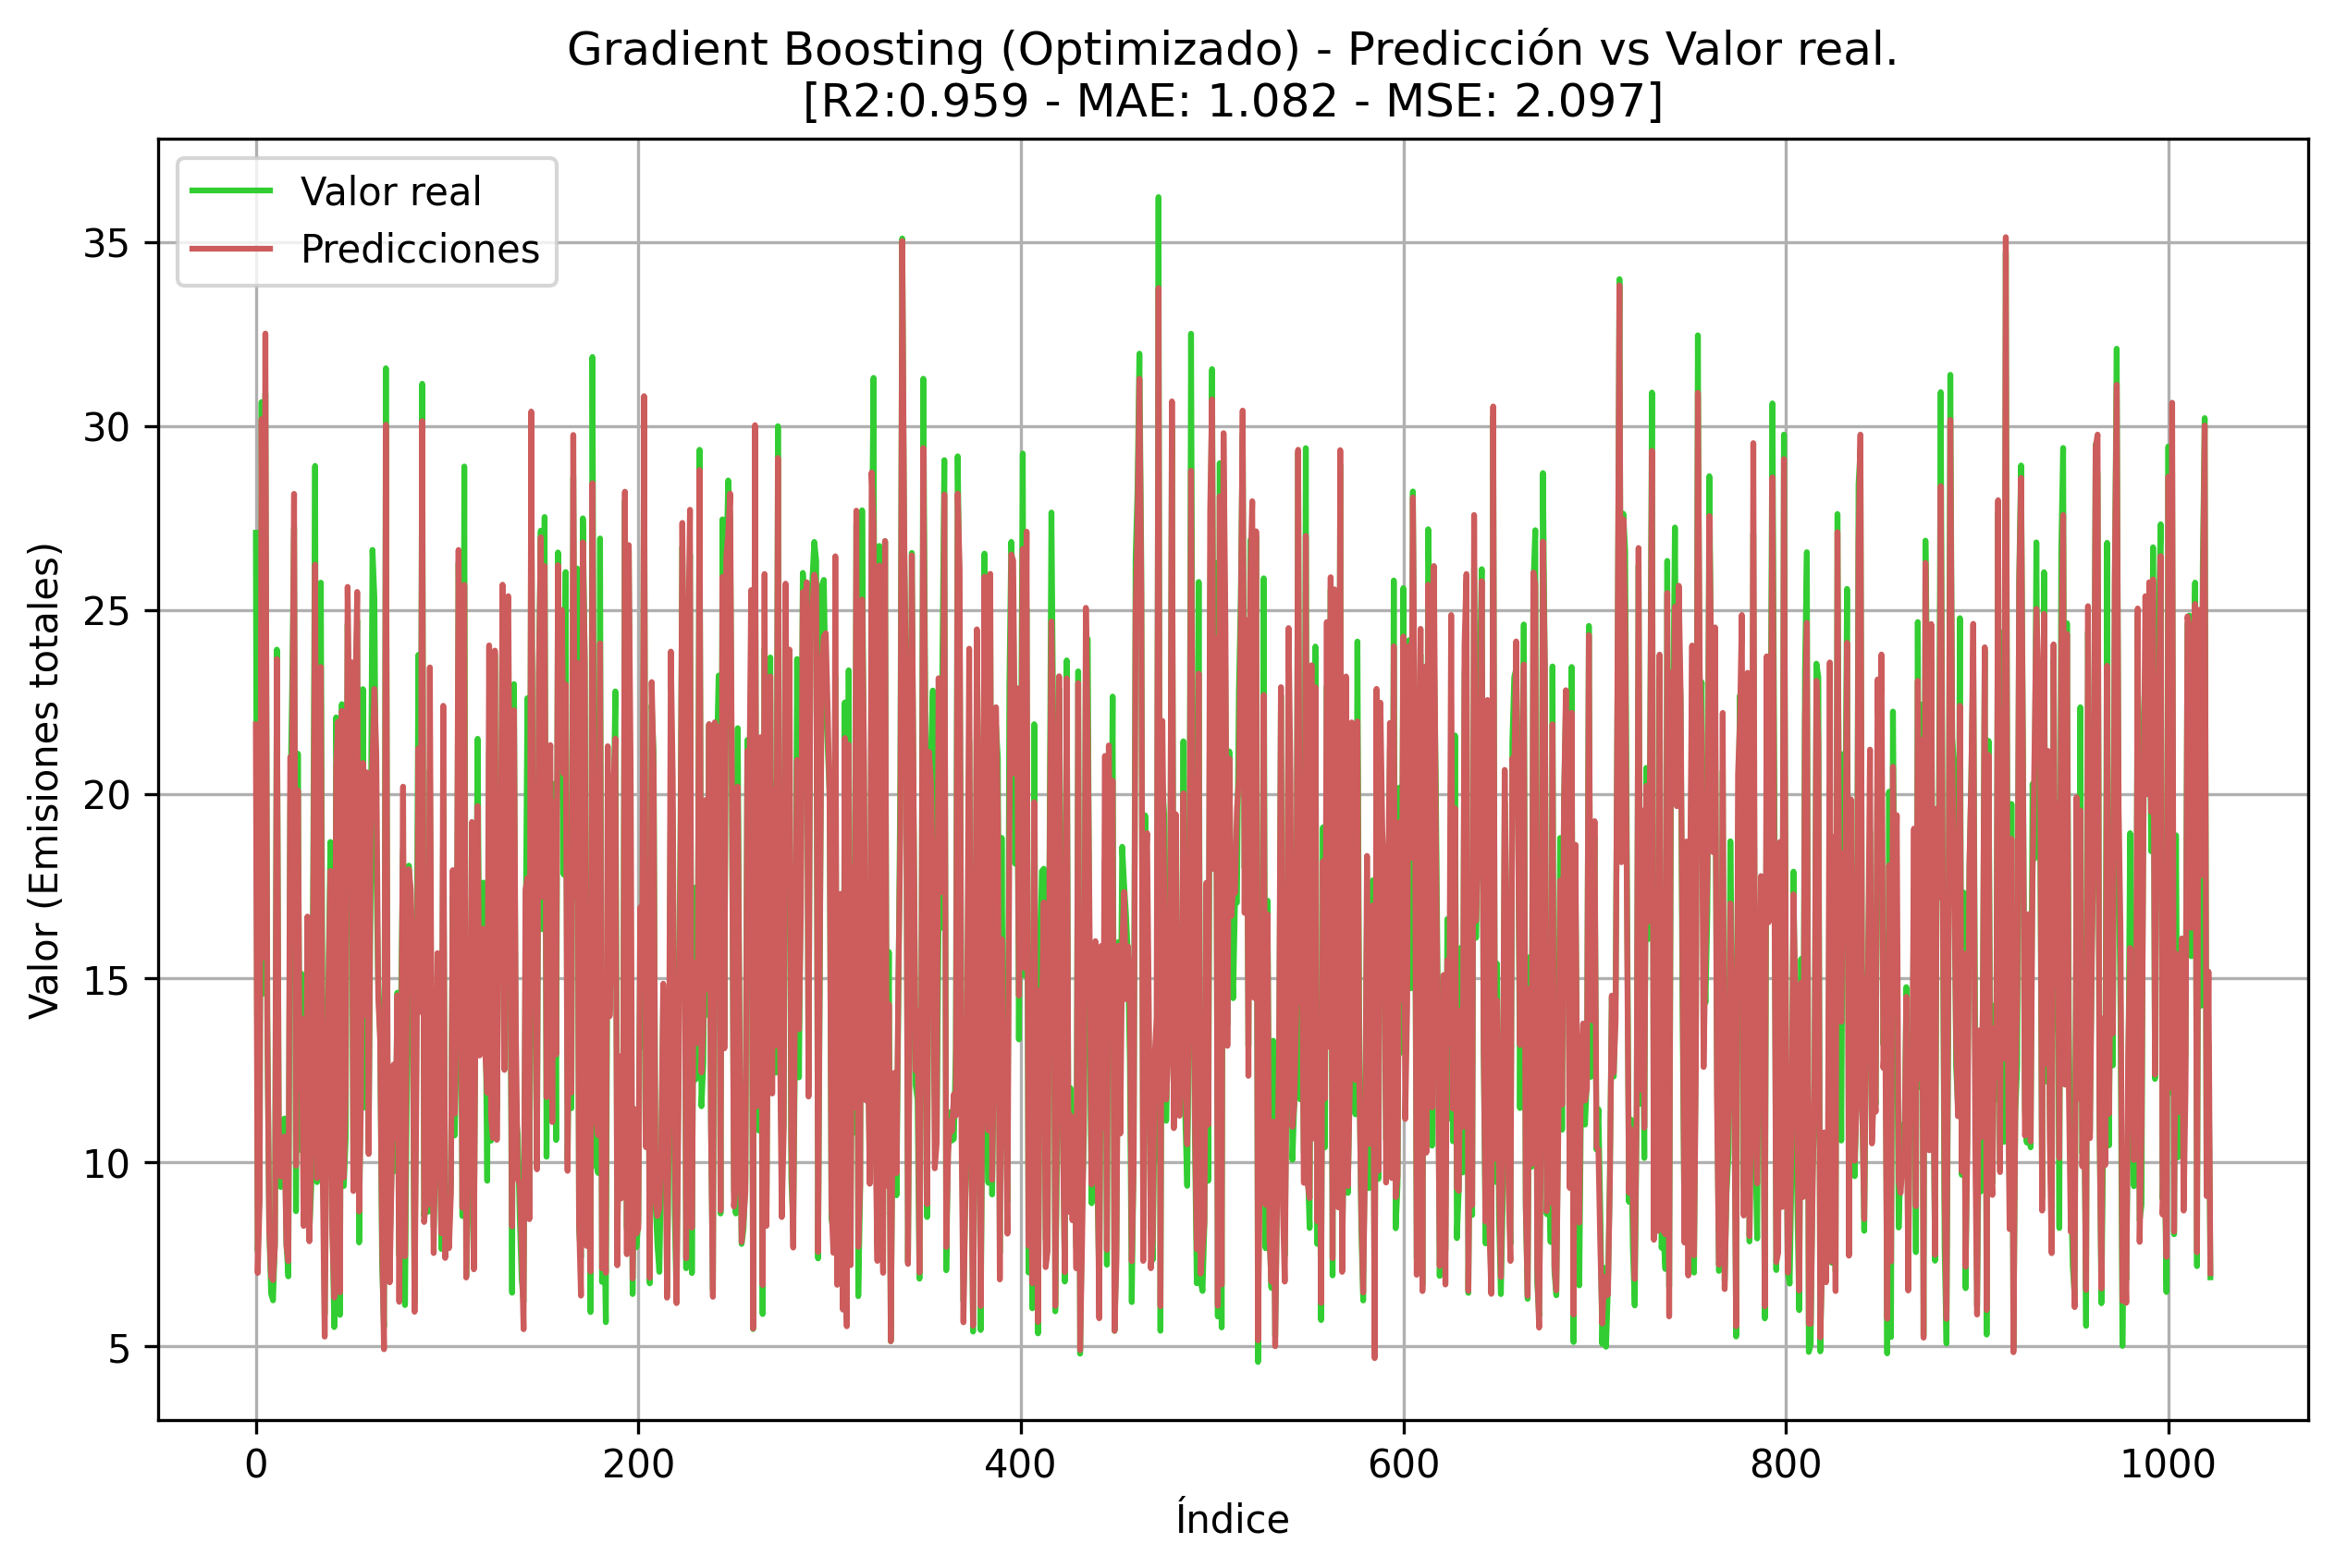

In [64]:
descripcion = f'Gradient Boosting (Optimizado) - Predicción vs Valor real.'
visualizarPrediccionesValorReal(Y_test, y_pred_gb_optimizado, descripcion, mae_gb_optimizado, mse_gb_optimizado, r2_gb_optimizado)
     